# Krog 2: Klasifikacija hiperspektralnih slik bakterijskih kolonij

## 1. Pregled podatkov

659 segmentiranih slik bakterijskih kolonij, 184 spektralnih pasov (452–948 nm). Ozadje je označeno z vrednostjo -1. Ker ima del slik reflektanco > 1 (nasičeni piksli), normaliziramo slike na 99. percentil pikslov kolonije.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np


data_path = Path("/d/hpc/projects/FRI/jn16867/ris/ris2026_krog2_ucni")
csv = pd.read_csv(data_path / "train.csv", header=None, names=['filename', 'label'])
lam = np.load(data_path / "lam.npy")

print(f"Podatkovni nabor: {len(csv)} slik, {len(lam)} pasov")
print(f"Razpon valovnih dolžin: {lam[0]:.1f} nm - {lam[-1]:.1f} nm (korak ~{lam[1]-lam[0]:.2f} nm)")


Dataset: 659 images, 184 bands
Wavelength range: 452.2 nm - 948.7 nm (step ~ 2.58 nm)



### Distribucija razredov

Število primerov na razred
label
Sepi     315
Saur     102
Efae      94
Ecoli     75
Kpne      34
Paer      18
Kaer      15
Spyo       6


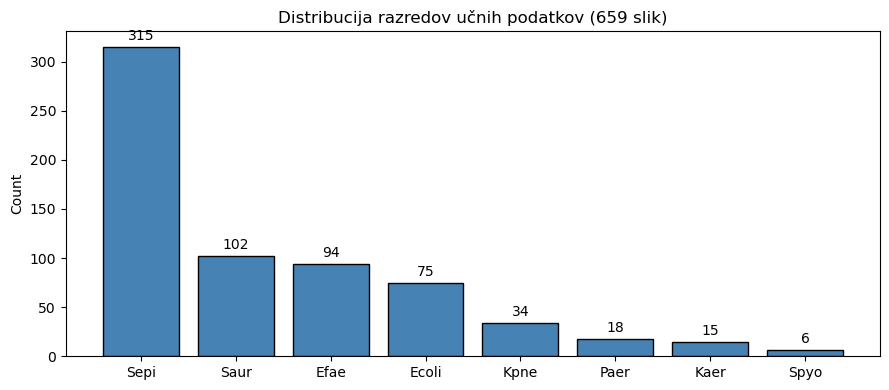

Razmerje neravnovesja (max/min): 52.5


In [3]:
from matplotlib import pyplot as plt

counts = csv['label'].value_counts()

print(f"Število primerov na razred") 
print(csv["label"].value_counts().to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(counts.index, counts.values, color="steelblue", edgecolor="black")
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4, str(v), ha="center", va="bottom", fontsize=10)
ax.set_title("Distribucija razredov učnih podatkov (659 slik)")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()
print("Razmerje neravnovesja (max/min):", round(counts.max() / counts.min(), 1))

### Ekstrakcija spektrov kolonij

Za vsako sliko izračunamo povprečni in standardni odklon spektra pikslov kolonije. Piksle odrežemo na 99. percentil, da odstranimo nasičene artefakte, nato normaliziramo z istim pragom.

In [62]:
records = []
label_map = dict(zip(csv['filename'], csv['label']))

for fpath in sorted(data_path.glob("*.npy")):
    if fpath.name == "lam.npy":
        continue
    label = label_map.get(fpath.name)
    if label is None:
        continue
    arr = np.load(fpath)
    H, W, C = arr.shape
    mask = arr[..., 0] != -1
    colony_px = mask.sum()
    if colony_px == 0:
        continue
    colony_vals = arr[mask]
    
    # clip na 99-tem percentilu pixlov kolonije
    pct = np.percentile(colony_vals[colony_vals >= 0], 99)
    colony_vals = np.clip(colony_vals, 0, pct)
    mean_spec = colony_vals.mean(axis=0) / pct # normaliziraj na [0, 1]
    std_spec = colony_vals.std(axis=0)

    records.append({
        "filename": fpath.name, "label": label,
        "H": H, "W": W, "colony_px": colony_px,
        "fill_frac": colony_px / (H * W),
        "mean_spec": mean_spec, "std_spec": std_spec,
        "max_refl": float(colony_vals.max())
    })
    
print(f"Naloženih {len(records)} slik")
meta = pd.DataFrame([{k : v for k, v in r.items() if k not in ("mean_spec", "std_spec")} for r in records])

Naloženih 659 slik


### Prostorska statistika

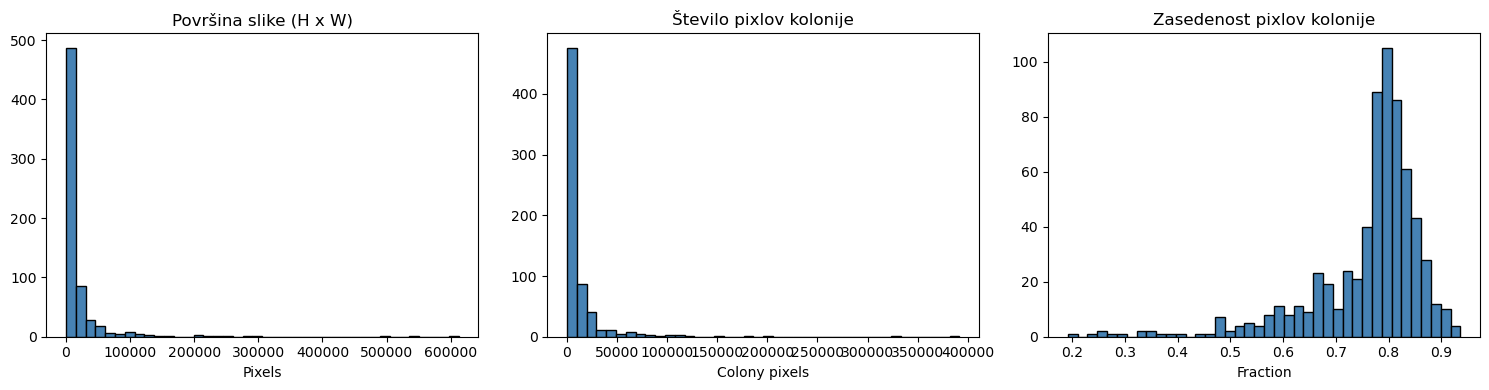

           H      W  colony_px  fill_frac
count  659.0  659.0      659.0      659.0
mean    91.4  102.7    12162.8        0.8
std     99.2  106.5    31035.8        0.1
min      5.0    8.0       42.0        0.2
25%     27.5   35.5      801.5        0.7
50%     61.0   70.0     3241.0        0.8
75%    121.0  136.5    12032.0        0.8
max    792.0  946.0   391606.0        0.9


In [63]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(meta["H"] * meta["W"], bins=40, color="steelblue", edgecolor="black")
axes[0].set_title("Površina slike (H x W)")
axes[0].set_xlabel("Pixels")
axes[1].hist(meta["colony_px"], bins=40, color="steelblue", edgecolor="black")
axes[1].set_title("Število pixlov kolonije")
axes[1].set_xlabel("Colony pixels")
axes[2].hist(meta["fill_frac"], bins=40, color="steelblue", edgecolor="black")
axes[2].set_title("Zasedenost pixlov kolonije")
axes[2].set_xlabel("Fraction")

plt.tight_layout()
plt.show()
print(meta[["H", "W", "colony_px", "fill_frac"]].describe().round(1).to_string())

### Povprečni spektri po razredih

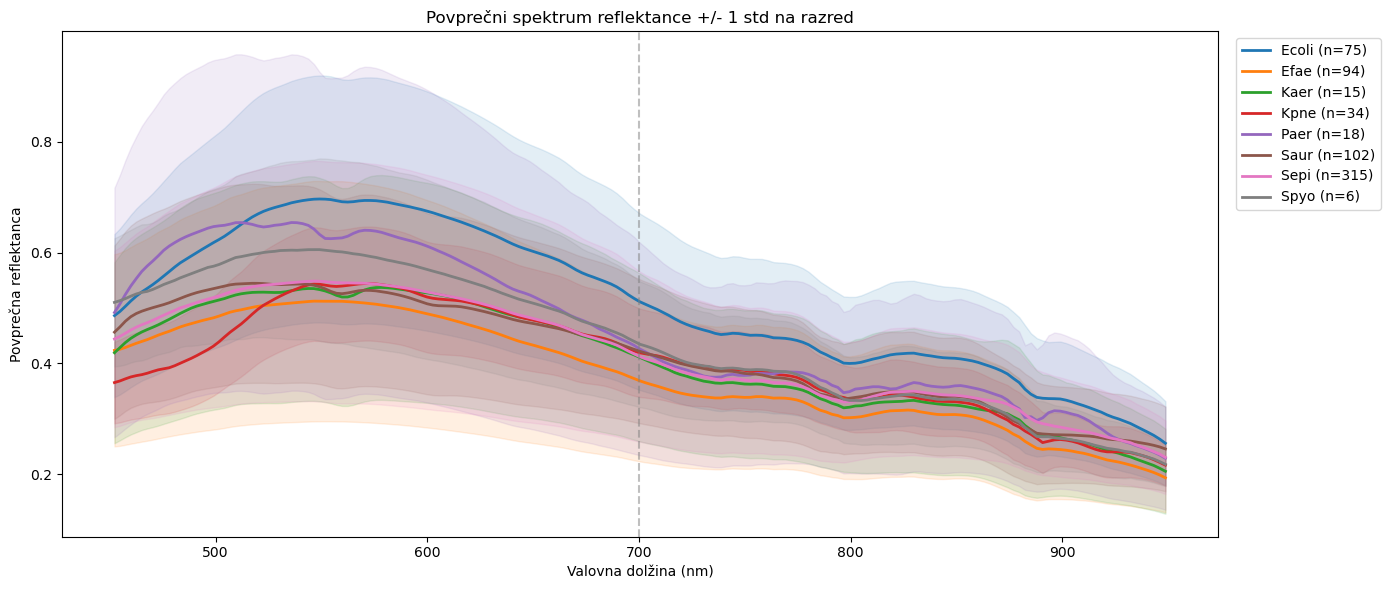

In [64]:
from collections import defaultdict

class_spectra = defaultdict(list)
for r in records:
    class_spectra[r["label"]].append(r["mean_spec"])
classes = sorted(class_spectra.keys())
colors = plt.cm.tab10(range(len(classes)))

fig, ax = plt.subplots(figsize=(14, 6))
for cls, color in zip(classes, colors):
    specs = np.array(class_spectra[cls])
    mu = specs.mean(axis=0)
    sigma = specs.std(axis=0)
    ax.plot(lam, mu, label=f"{cls} (n={len(specs)})", color=color, lw=2)
    ax.fill_between(lam, mu - sigma, mu + sigma, color=color, alpha=0.12)
ax.set_xlabel("Valovna dolžina (nm)")
ax.set_ylabel("Povprečna reflektanca")
ax.set_title("Povprečni spektrum reflektance +/- 1 std na razred")
ax.axvline(700, ls="--", color="gray", alpha=0.5)
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left")

plt.tight_layout()
plt.show()

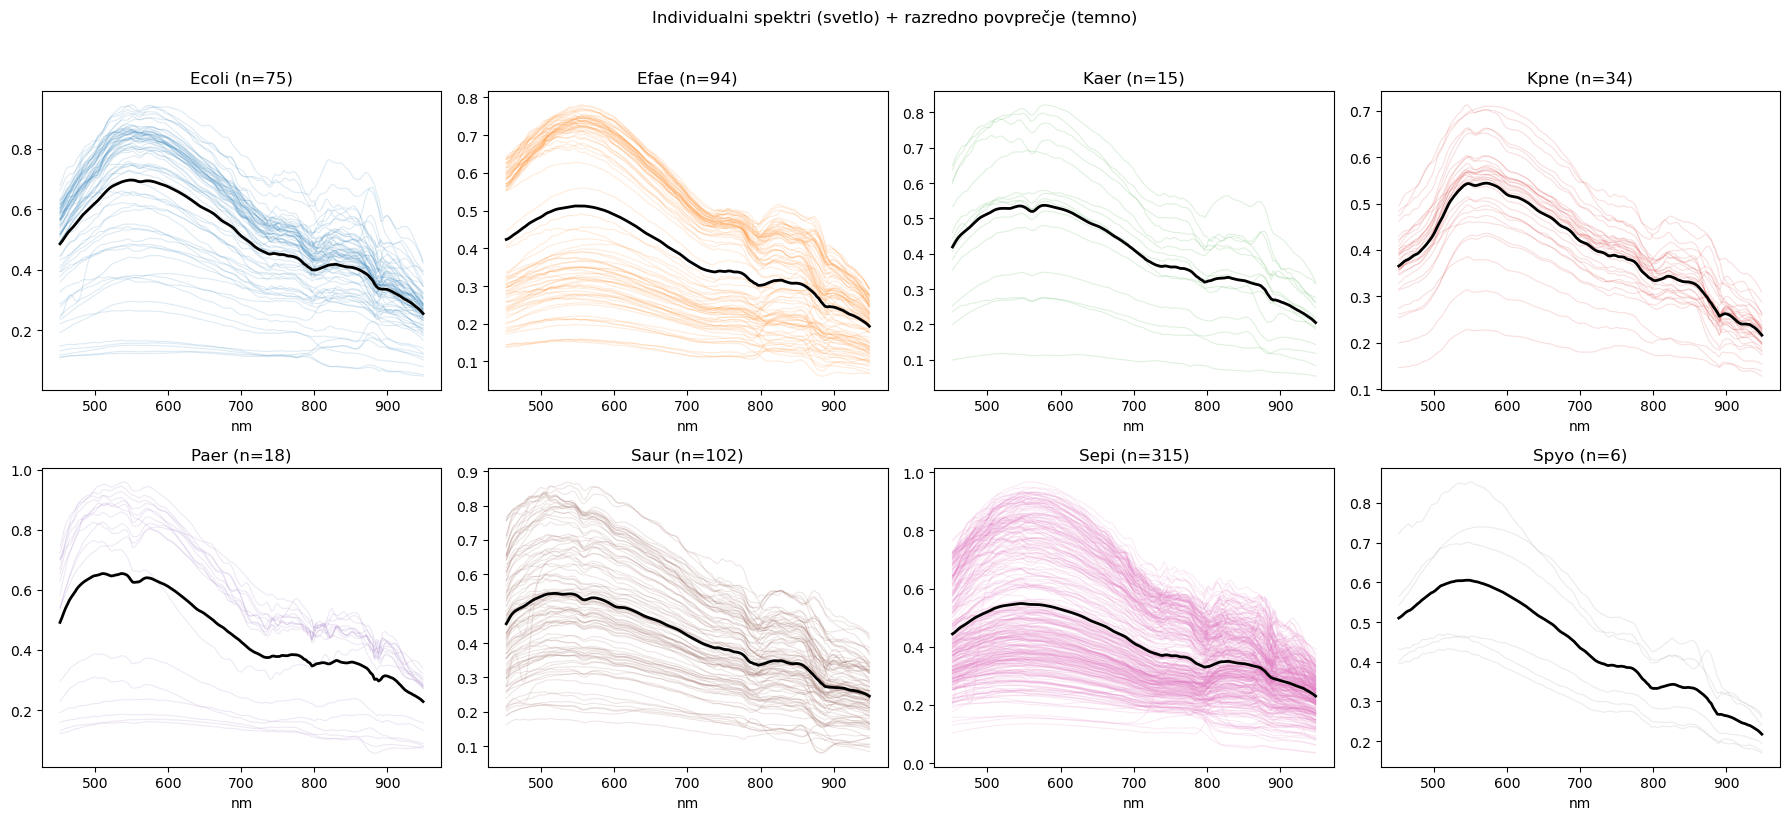

In [ ]:
# Variabilnost znotraj razredov
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)
for ax, (cls, color) in zip(axes.flat, zip(classes, colors)):
    specs = np.array(class_spectra[cls])
    mu = specs.mean(axis=0)
    for s in specs:
        ax.plot(lam, s, color=color, alpha=0.15, lw=0.8)
    ax.plot(lam, mu, color="black", lw=2)
    ax.set_title(f"{cls} (n={len(specs)})")
    ax.set_xlabel("Valovna dolžina (nm)")
    ax.set_ylabel("Reflektanca")
for ax in axes.flat[len(classes):]:
    ax.set_visible(False)
plt.suptitle("Intra-class variabilnost spektrov", y=1.01)
plt.tight_layout()
plt.show()


### PCA - Spektralna ločljivost

Razložena varianca na PC (%) [93.3  4.7  0.9  0.4  0.2  0.1]
Kumulativno (6 PCs) 99.7 %


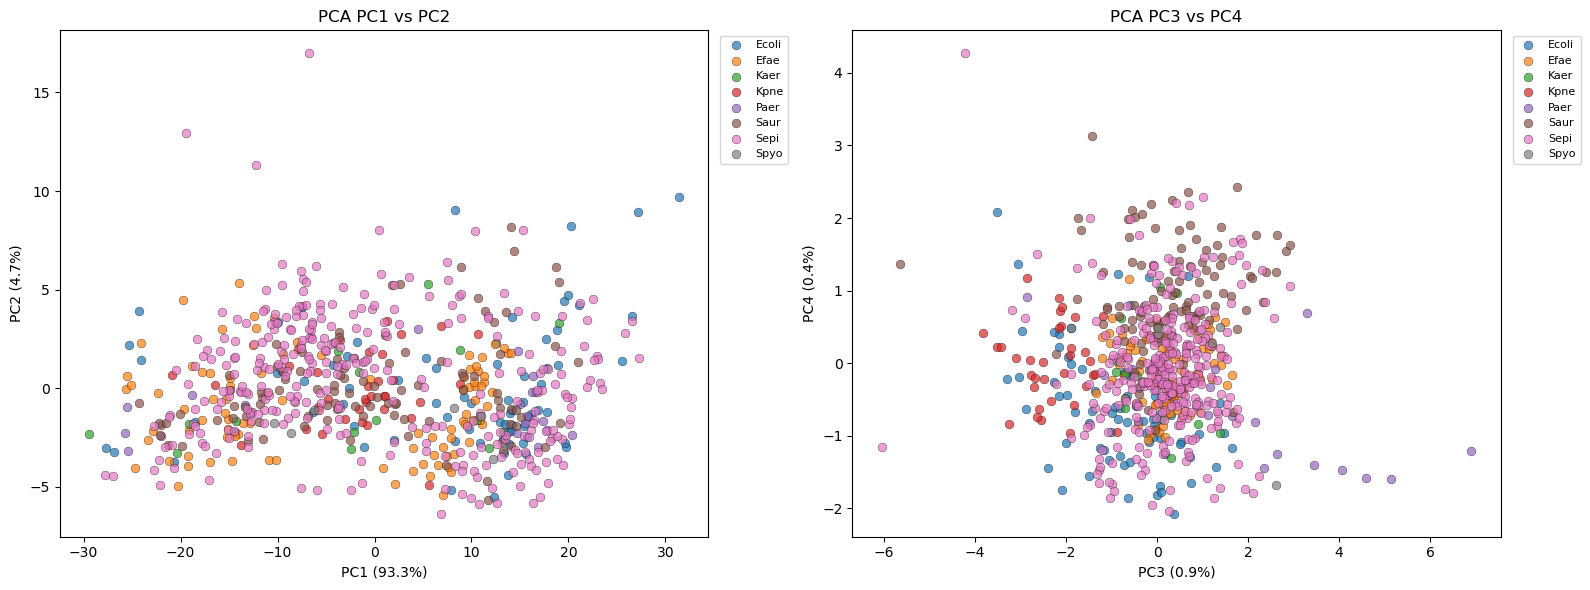

In [66]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = np.clip(np.array([r["mean_spec"] for r in records]), 0, 2.0)
y = np.array([r["label"] for r in records])

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=10)
X_pca = pca.fit_transform(X_scaled)

print("Razložena varianca na PC (%)", np.round(pca.explained_variance_ratio_[:6] * 100, 1))
print("Kumulativno (6 PCs)", np.round(pca.explained_variance_ratio_[:6].sum() * 100, 1), "%")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (pc_x, pc_y) in zip(axes, [(0, 1), (2, 3)]):
    for cls, color in zip(classes, colors):
        mask = y == cls
        ax.scatter(
            X_pca[mask, pc_x],
            X_pca[mask, pc_y],
            label=cls,
            color=color,
            alpha=0.7,
            s=40,
            edgecolors="k",
            linewidths=0.3,
        )
    ax.set_xlabel(f"PC{pc_x+1} ({pca.explained_variance_ratio_[pc_x]*100:.1f}%)")
    ax.set_ylabel(f"PC{pc_y+1} ({pca.explained_variance_ratio_[pc_y]*100:.1f}%)")
    ax.set_title(f"PCA PC{pc_x+1} vs PC{pc_y+1}")
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

### Katere valovne dolžine so najbolj diskriminativne?

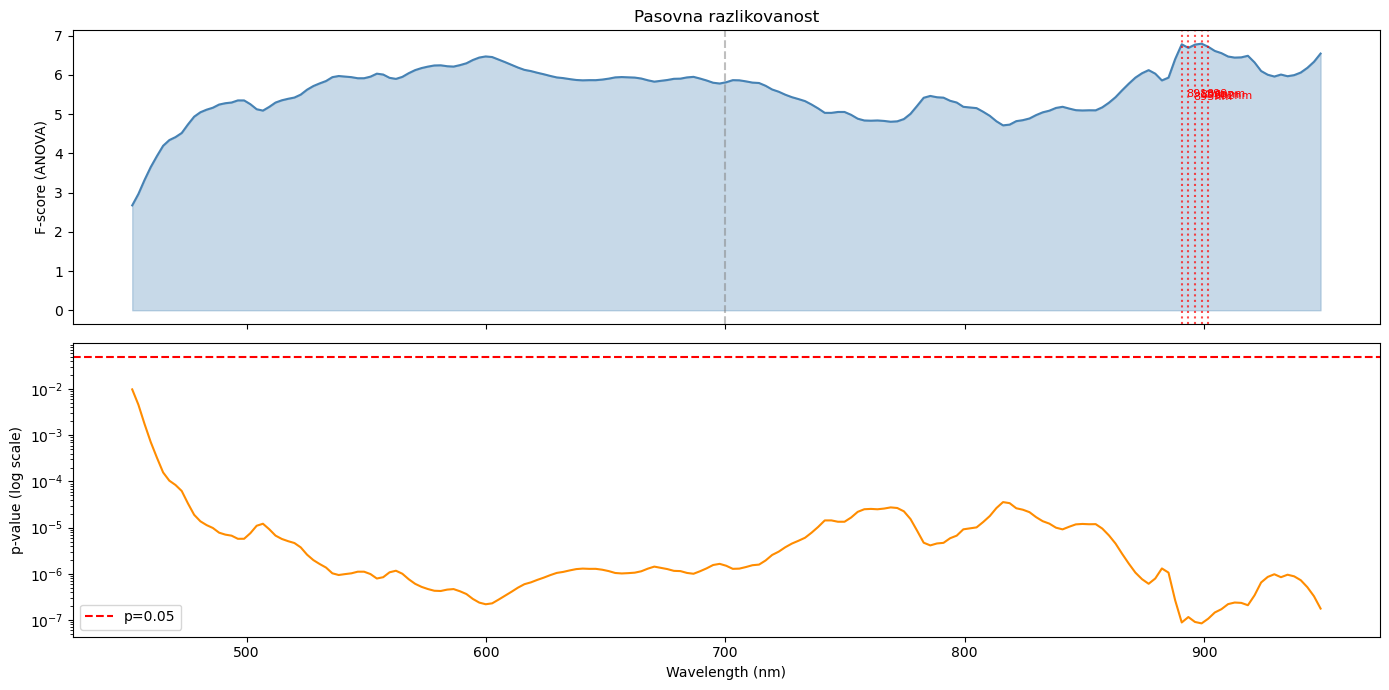

Top 10 najbolj diskriminativnih valovnih dolžin:
  899.0 nm  (F=6.8)
  890.7 nm  (F=6.8)
  896.2 nm  (F=6.8)
  901.8 nm  (F=6.7)
  893.5 nm  (F=6.7)
  904.5 nm  (F=6.6)
  907.3 nm  (F=6.6)
  948.7 nm  (F=6.5)
  918.4 nm  (F=6.5)
  599.9 nm  (F=6.5)


In [67]:
from sklearn.feature_selection import f_classif

F_scores, p_values = f_classif(X, y)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
ax1.plot(lam, F_scores, color="steelblue", lw=1.5)
ax1.fill_between(lam, 0, F_scores, alpha=0.3, color="steelblue")
ax1.set_ylabel("F-score (ANOVA)")
ax1.set_title("Pasovna razlikovanost")
ax1.axvline(700, ls="--", color="gray", alpha=0.5)
top5 = np.argsort(F_scores)[-5:]
for idx in top5:
    ax1.axvline(lam[idx], ls=":", color="red", alpha=0.7)
    ax1.text(
        lam[idx] + 2, F_scores[idx] * 0.8, f"{lam[idx]:.0f}nm", fontsize=8, color="red"
    )
ax2.semilogy(lam, p_values + 1e-300, color="darkorange", lw=1.5)
ax2.axhline(0.05, ls="--", color="red", label="p=0.05")
ax2.set_ylabel("p-value (log scale)")
ax2.set_xlabel("Wavelength (nm)")
ax2.legend()
plt.tight_layout()
plt.show()

print("10 najbolj diskriminativnih valovnih dolžin:")
for idx in np.argsort(F_scores)[-10:][::-1]:
    print(f"  {lam[idx]:.1f} nm  (F={F_scores[idx]:.1f})")

### Psevdo RGB vizualizacija

Psevdo-RGB pasovi: R=651nm, G=549nm, B=452nm


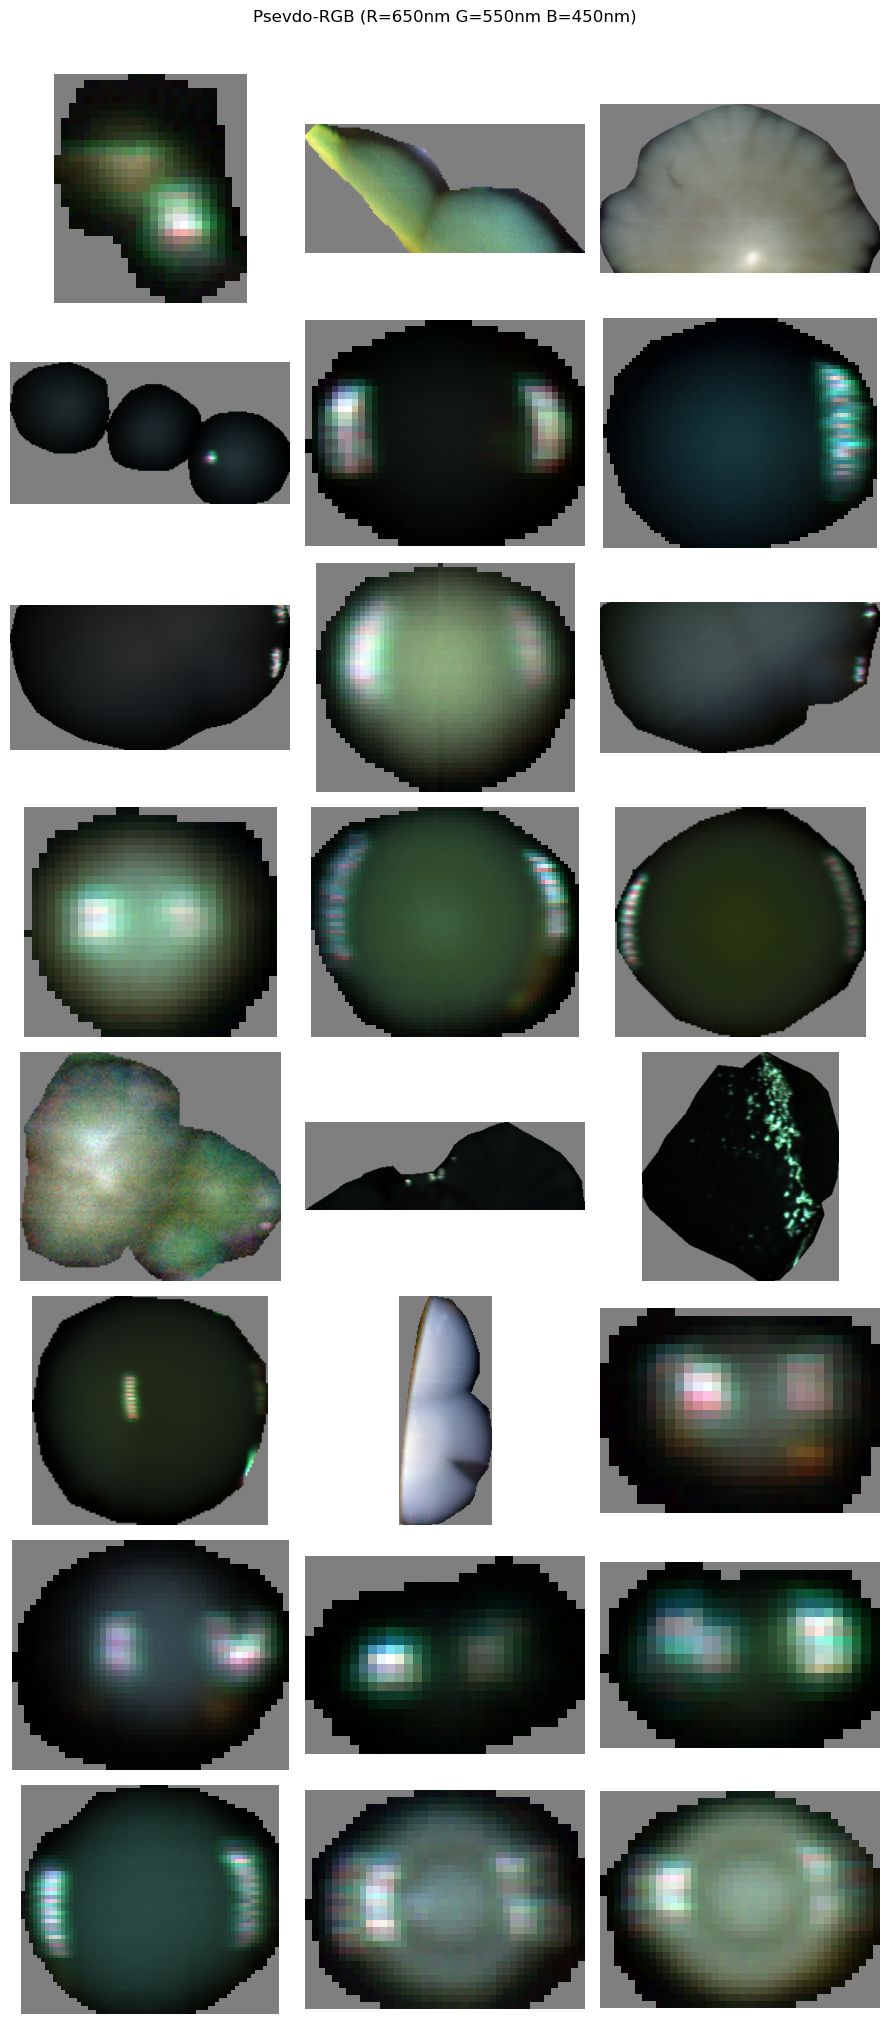

In [68]:
def band_idx(target_nm):
    return int(np.argmin(np.abs(lam - target_nm)))

rgb_bands = [band_idx(650), band_idx(550), band_idx(450)]
print(
    f"Psevdo-RGB pasovi: R={lam[rgb_bands[0]]:.0f}nm, G={lam[rgb_bands[1]]:.0f}nm, B={lam[rgb_bands[2]]:.0f}nm"
)

def to_pseudoRGB(arr, bands=rgb_bands):
    rgb = arr[..., bands].astype(float)
    bg = arr[..., 0] == -1
    for c in range(3):
        ch = rgb[..., c]
        vmin, vmax = ch[~bg].min(), ch[~bg].max()
        rgb[..., c] = (ch - vmin) / (vmax - vmin + 1e-8)
    rgb[bg] = 0.5
    return np.clip(rgb, 0, 1)

file_by_class = defaultdict(list)
for r in records:
    file_by_class[r["label"]].append(r["filename"])

n_show = 3
fig, axes = plt.subplots(len(classes), n_show, figsize=(n_show * 3, len(classes) * 2.5))
for row, cls in enumerate(classes):
    files = file_by_class[cls][:n_show]
    for col, fname in enumerate(files):
        arr = np.load(data_path / fname)
        axes[row, col].imshow(to_pseudoRGB(arr))
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(
                cls, fontsize=11, rotation=0, labelpad=40, va="center"
            )
    for col in range(len(files), n_show):
        axes[row, col].axis("off")

plt.suptitle("Psevdo-RGB (R=650nm G=550nm B=450nm)", y=1.01)
plt.tight_layout()
plt.show()

### Spektralna podobnost med razredi

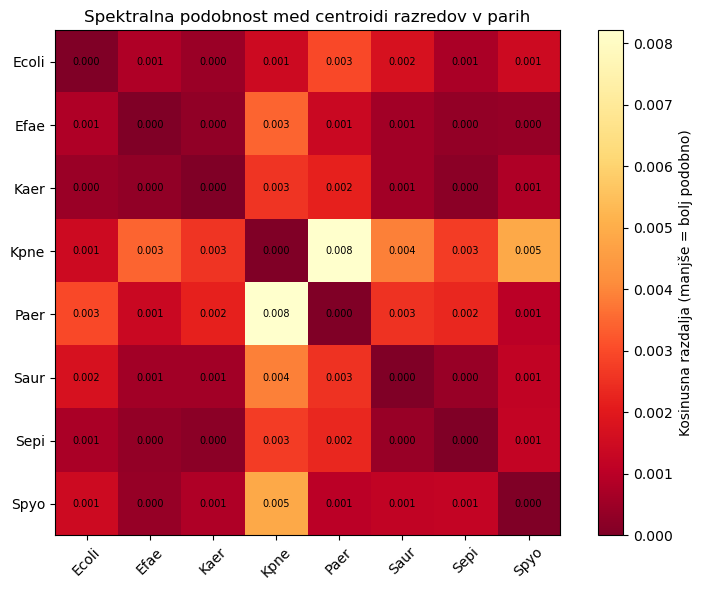

Najbolj spektralno podobni pari:
  Kaer <-> Sepi:  cosine_dist=0.00022
  Efae <-> Kaer:  cosine_dist=0.00031
  Efae <-> Sepi:  cosine_dist=0.00033
  Efae <-> Spyo:  cosine_dist=0.00040
  Saur <-> Sepi:  cosine_dist=0.00042


In [69]:
from scipy.spatial.distance import cdist

centroids = {cls: np.array(class_spectra[cls]).mean(axis=0) for cls in classes}
centroid_mat = np.array([centroids[c] for c in classes])
dist = cdist(centroid_mat, centroid_mat, metric="cosine")

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(dist, cmap="YlOrRd_r")
ax.set_xticks(range(len(classes)))
ax.set_xticklabels(classes, rotation=45)
ax.set_yticks(range(len(classes)))
ax.set_yticklabels(classes)
plt.colorbar(im, ax=ax, label="Kosinusna razdalja (manjše = bolj podobno)")
ax.set_title("Spektralna podobnost med centroidi razredov v parih")
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f"{dist[i,j]:.3f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()

pairs = [
    (dist[i, j], classes[i], classes[j])
    for i in range(len(classes))
    for j in range(i + 1, len(classes))
]
print("Najbolj spektralno podobni pari:")
for d, a, b in sorted(pairs)[:5]:
    print(f"  {a} <-> {b}:  cosine_dist={d:.5f}")

### Kvaliteta podatkov

In [70]:
over1 = [
    (r["filename"], r["label"], r["max_refl"]) for r in records if r["max_refl"] > 1.0
]
print(f"Slike z max reflektanco > 1.0: {len(over1)} / {len(records)}")
for fname, lbl, mx in sorted(over1, key=lambda x: -x[2])[:10]:
    print(f"  {fname}  [{lbl}]  max={mx:.3f}")
print()
tiny = [
    (r["filename"], r["label"], r["colony_px"]) for r in records if r["colony_px"] < 200
]
print(f"Slike z < 200 pixli kolonije: {len(tiny)}")
for fname, lbl, npx in sorted(tiny, key=lambda x: x[2]):
    print(f"  {fname}  [{lbl}]  px={npx}")
print()
print("Intra-class spektralna spremenljivost (mean std prek pasov):")
for cls in classes:
    specs = np.array(class_spectra[cls])
    print(
        f"  {cls:6s}  n={len(specs):3d}  mean-intra-std={specs.std(axis=0).mean():.4f}"
    )

Slike z max reflektanco > 1.0: 32 / 659
  17688460effb89ac.npy  [Saur]  max=2.208
  669d2c587382bb30.npy  [Ecoli]  max=2.027
  677e013646de4e9b.npy  [Sepi]  max=1.878
  73695b1d784fbc67.npy  [Sepi]  max=1.849
  43f37245a949e794.npy  [Saur]  max=1.725
  f7a227b973b2f358.npy  [Efae]  max=1.611
  4532cb6b248fa3cd.npy  [Kaer]  max=1.584
  7da90af482b09f54.npy  [Ecoli]  max=1.553
  7dcc0c78b0def4f4.npy  [Efae]  max=1.552
  e1fc8f5749cf43f5.npy  [Saur]  max=1.544

Slike z < 200 pixli kolonije: 50
  6769726f70ad0a30.npy  [Sepi]  px=42
  bacf8fda4c9f920d.npy  [Sepi]  px=54
  7a990cc789bbff45.npy  [Sepi]  px=58
  60228020fc0220d9.npy  [Sepi]  px=73
  57cbb214339c79e8.npy  [Sepi]  px=76
  6987d12aace62c60.npy  [Sepi]  px=77
  81676a379621ff7c.npy  [Sepi]  px=81
  509997af7885e95b.npy  [Sepi]  px=82
  7712836c61d0a72a.npy  [Sepi]  px=85
  24e1eb856ea88f9a.npy  [Sepi]  px=89
  1e978d672cead7de.npy  [Sepi]  px=93
  7d09cb90fed31b67.npy  [Sepi]  px=95
  2428aee45ef7d956.npy  [Sepi]  px=98
  53141ae9

## 2. Osnovni ML Baseline

In [71]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

X_mean = np.clip(np.array([r["mean_spec"] for r in records]), 0, 2.0)
X_std = np.clip(np.array([r["std_spec"] for r in records]), 0, 2.0)
X_full = np.hstack([X_mean, X_std]) # 368 features
y_all = np.array([r["label"] for r in records])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "SVM-RBF (mean only)": (
        Pipeline(
            [
                ("sc", StandardScaler()),
                ("m", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")),
            ]
        ),
        X_mean,
    ),
    "SVM-RBF (mean+std)": (
        Pipeline(
            [
                ("sc", StandardScaler()),
                ("m", SVC(kernel="rbf", C=10, gamma="scale", class_weight="balanced")),
            ]
        ),
        X_full,
    ),
    "SVM-Lin (mean+std)": (
        Pipeline(
            [
                ("sc", StandardScaler()),
                ("m", SVC(kernel="linear", C=1, class_weight="balanced")),
            ]
        ),
        X_full,
    ),
    "RF (mean+std)": (
        RandomForestClassifier(
            n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
        ),
        X_full,
    ),
    "LR (mean+std)": (
        Pipeline(
            [
                ("sc", StandardScaler()),
                ("m", LogisticRegression(C=1, max_iter=1000, class_weight="balanced")),
            ]
        ),
        X_full,
    ),
}

for name, (model, X_model) in models.items():
    sc = cross_val_score(model, X_model, y_all, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"{name:30s}  {sc.mean():.3f} +/- {sc.std():.3f}")

SVM-RBF (mean only)             0.543 +/- 0.021
SVM-RBF (mean+std)              0.552 +/- 0.051
SVM-Lin (mean+std)              0.727 +/- 0.062
RF (mean+std)                   0.704 +/- 0.016
LR (mean+std)                   0.671 +/- 0.058


Nastavi hiperparametre linearnega SVM-ja.

In [72]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_params = [0.01, 0.1, 1, 10, 100]

for C in C_params:
    model = Pipeline(
        [
            ("sc", StandardScaler()),
            ("m", SVC(kernel="linear", C=C, class_weight="balanced")),
        ]
    )
    sc = cross_val_score(model, X_full, y_all, cv=cv, scoring="accuracy", n_jobs=1)
    print(f"{C:.2f}  {sc.mean():.3f} +/- {sc.std():.3f}")

0.01  0.382 +/- 0.025
0.10  0.563 +/- 0.048
1.00  0.727 +/- 0.062
10.00  0.829 +/- 0.028
100.00  0.844 +/- 0.030


Nastavi hiperparametre linearnega SVM-ja z uporabo PCA komponent

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
C_params = [0.01, 0.1, 1, 10, 100]
n_components = [5, 10, 20, 50]
X_scaled = StandardScaler().fit_transform(X_full)

for n in n_components:
    pca = PCA(n_components=n)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"PCA with {n} components")
    for C in C_params:
        model = Pipeline(
            [
                ("sc", StandardScaler()),
                ("m", SVC(kernel="linear", C=C, class_weight="balanced")),
            ]
        )
        sc = cross_val_score(model, X_pca, y_all, cv=cv, scoring="accuracy", n_jobs=1)
        print(f"{C:.2f}  {sc.mean():.3f} +/- {sc.std():.3f}")
    print("\n")

PCA with 5 components
0.01  0.232 +/- 0.041
0.10  0.343 +/- 0.015
1.00  0.346 +/- 0.034
10.00  0.349 +/- 0.047
100.00  0.350 +/- 0.048


PCA with 10 components
0.01  0.346 +/- 0.039
0.10  0.446 +/- 0.026
1.00  0.484 +/- 0.029
10.00  0.478 +/- 0.025
100.00  0.487 +/- 0.024


PCA with 20 components
0.01  0.624 +/- 0.066
0.10  0.690 +/- 0.053
1.00  0.730 +/- 0.038
10.00  0.760 +/- 0.036
100.00  0.760 +/- 0.027


PCA with 50 components
0.01  0.812 +/- 0.022
0.10  0.830 +/- 0.023
1.00  0.848 +/- 0.009
10.00  0.833 +/- 0.021
100.00  0.835 +/- 0.018




## 3. Evaluacija baseline modela (kje so napake?)

### Matrika napak

Izračunamo napovedi s prečnim preverjanjem (5-fold CV) in prikažemo matriko napak ter poročilo o klasifikaciji.

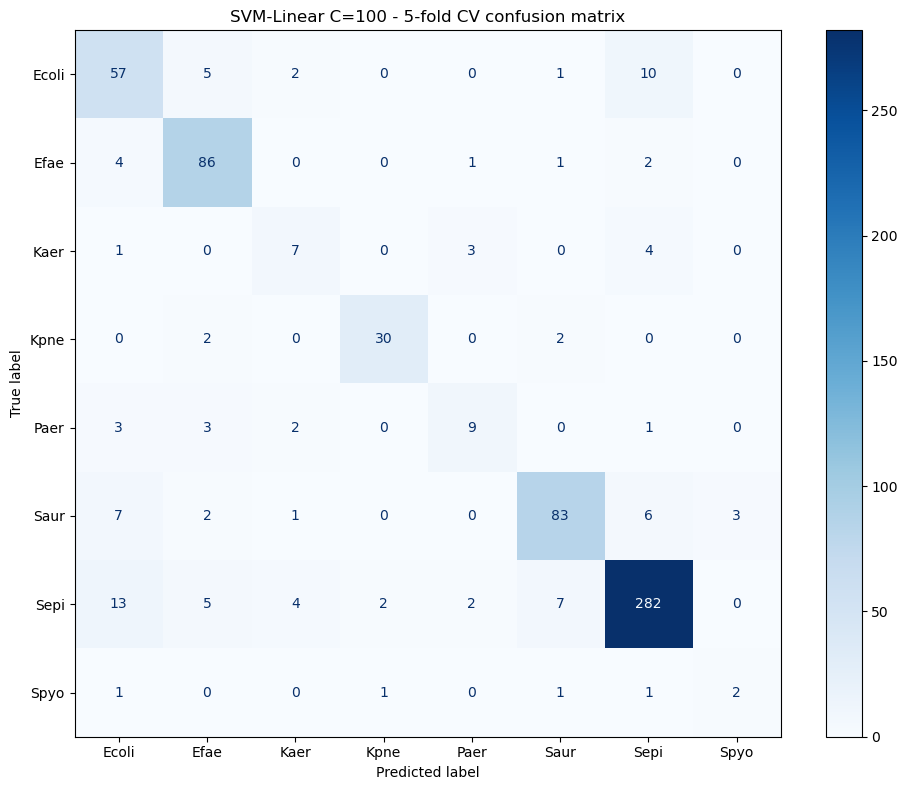

              precision    recall  f1-score   support

       Ecoli       0.66      0.76      0.71        75
        Efae       0.83      0.91      0.87        94
        Kaer       0.44      0.47      0.45        15
        Kpne       0.91      0.88      0.90        34
        Paer       0.60      0.50      0.55        18
        Saur       0.87      0.81      0.84       102
        Sepi       0.92      0.90      0.91       315
        Spyo       0.40      0.33      0.36         6

    accuracy                           0.84       659
   macro avg       0.70      0.70      0.70       659
weighted avg       0.85      0.84      0.84       659



In [74]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

best_model = Pipeline([
    ("sc", StandardScaler()),
    ("m", SVC(kernel="linear", C=100, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(best_model, X_full, y_all, cv=cv)

classes_sorted = sorted(set(y_all))
cm = confusion_matrix(y_all, y_pred, labels=classes_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(cm, display_labels=classes_sorted)
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title("SVM-Linear C=100 - 5-fold CV confusion matrix")
plt.tight_layout()
plt.show()

print(classification_report(y_all, y_pred, target_names=classes_sorted))

Prikažimo narobe klasificirane slike (ime slike, pravi razred, klasificiran razred)

In [76]:
from collections import Counter

fnames = np.array([r["filename"] for r in records])

wrong_mask = y_pred != y_all
wrong_files = fnames[wrong_mask]
wrong_true = y_all[wrong_mask]
wrong_pred = y_pred[wrong_mask]

print(f"Skupno narobe klasificirano: {wrong_mask.sum()} / {len(y_all)}\n")
print("Najbolj pogosti napačno klasificirani pari (true -> pred):")
pairs = Counter(zip(wrong_true, wrong_pred))
for (t, p), cnt in pairs.most_common(15):
    print(f"  {t:6s} -> {p:6s}  x{cnt}")

Skupno narobe klasificirano: 103 / 659

Najbolj pogosti napačno klasificirani pari (true -> pred):
  Sepi   -> Ecoli   x13
  Ecoli  -> Sepi    x10
  Saur   -> Ecoli   x7
  Sepi   -> Saur    x7
  Saur   -> Sepi    x6
  Ecoli  -> Efae    x5
  Sepi   -> Efae    x5
  Kaer   -> Sepi    x4
  Efae   -> Ecoli   x4
  Sepi   -> Kaer    x4
  Saur   -> Spyo    x3
  Paer   -> Ecoli   x3
  Kaer   -> Paer    x3
  Paer   -> Efae    x3
  Sepi   -> Paer    x2


Na katerih razredih je boljša/slabša klasifikacijska točnost?

In [107]:
y_pred_best = cross_val_predict(best_model, X_full, y_all, cv=cv)

print("Razredna točnost (SVM-Lin C=100):")
print(f'  {"Class":8s}  {"n_train":>8s}  {"correct":>8s}  {"acc":>8s}')
for cls in classes_sorted:
    mask = y_all == cls
    correct = (y_pred_best[mask] == cls).sum()
    total = mask.sum()
    print(f"  {cls:8s}  {total:8d}  {correct:8d}   {correct/total:.3f}")

Razredna točnost (SVM-Lin C=100):
  Class      n_train   correct       acc
  Ecoli           75        57   0.760
  Efae            94        86   0.915
  Kaer            15         7   0.467
  Kpne            34        30   0.882
  Paer            18         9   0.500
  Saur           102        83   0.814
  Sepi           315       282   0.895
  Spyo             6         2   0.333


Oglejmo si slike z zelo majhno površino kolonije

In [145]:
from collections import Counter

counts = Counter(r["label"] for r in records if r["colony_px"] < 200)
counts

Counter({'Sepi': 49, 'Ecoli': 1})

Opazimo, da je 49/50 zelo majhnih slik razreda Sepi. Lahko so šum (segmentacija vsebuje del agarja). Za test izločimo slike z <200px kolonije in ponovno natreniramo model.

In [147]:
keep = np.array([r["colony_px"] >= 200 for r in records])
X_filtered = X_full[keep]
y_filtered = y_all[keep]
print(
    f"Ohranjenih {keep.sum()} / {len(keep)} slik (izločenih {(~keep).sum()} slik z majhnimi kolonijami)"
)

cv_f = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
sc_filt = cross_val_score(
    best_model, X_filtered, y_filtered, cv=cv_f, scoring="accuracy", n_jobs=-1
)
print(f"SVM-Lin C=100 (filtrirani podatki):   {sc_filt.mean():.3f} +/- {sc_filt.std():.3f}")
sc_all = cross_val_score(
    best_model, X_full, y_all, cv=cv, scoring="accuracy", n_jobs=-1
)
print(f"SVM-Lin C=100 (vsi podatki):   {sc_all.mean():.3f} +/- {sc_all.std():.3f}")

Ohranjenih 609 / 659 slik (izločenih 50 slik z majhnimi kolonijami)
SVM-Lin C=100 (filtrirani podatki):   0.816 +/- 0.032
SVM-Lin C=100 (vsi podatki):   0.844 +/- 0.030


Podrobneje si oglejmo slike razrede Spyo, za katere imamo le 6 primerkov. Le 2/6 smo pravilno klasificirali. Kako zgledajo spektri?

Spyo število pixlov kolonij: [3074, 1116, 1001, 5004, 1473, 1275]
Spyo velikosti slik: [(58, 65), (32, 41), (31, 40), (79, 79), (44, 58), (38, 41)]


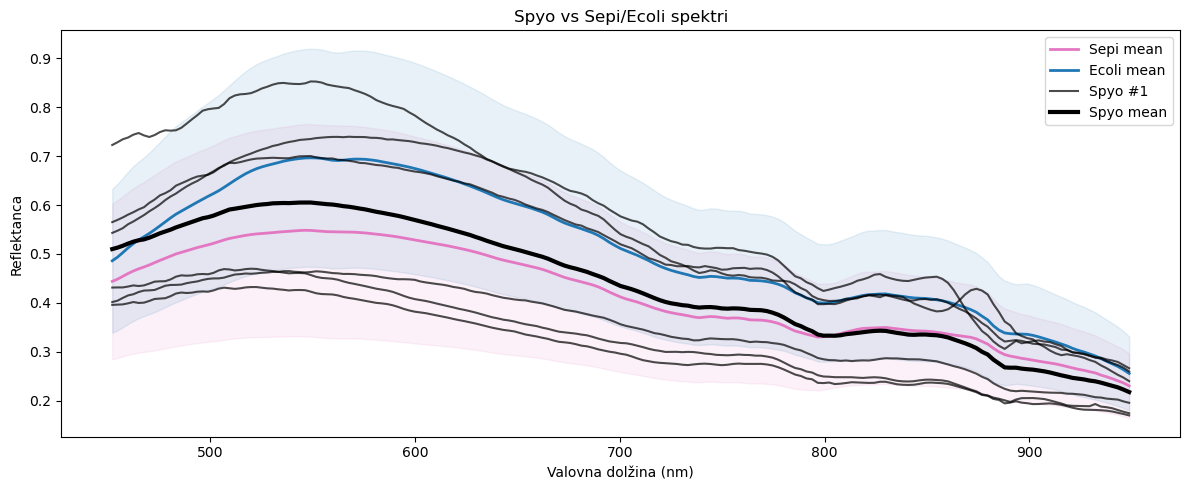

In [159]:
spyo_records = [r for r in records if r["label"] == "Spyo"]
print(f'Spyo število pixlov kolonij: {[int(r["colony_px"]) for r in spyo_records]}')
print(f'Spyo velikosti slik: {[(r["H"], r["W"]) for r in spyo_records]}')

# Prikaži Spyo spektre proti njihovim najbližjim razredom (Sepi, Ecoli)
fig, ax = plt.subplots(figsize=(12, 5))
for cls, lw, alpha in [("Sepi", 1, 0.1), ("Ecoli", 1, 0.2)]:
    specs = np.array(class_spectra[cls])
    mu = specs.mean(axis=0)
    sigma = specs.std(axis=0)
    color = colors[classes.index(cls)]
    ax.plot(lam, mu, color=color, lw=2, label=f"{cls} mean")
    ax.fill_between(lam, mu - sigma, mu + sigma, color=color, alpha=0.1)

spyo_specs = np.array(class_spectra["Spyo"])
for i, s in enumerate(spyo_specs):
    ax.plot(
        lam,
        s,
        color="black",
        lw=1.5,
        alpha=0.7,
        label=f"Spyo #{i+1}" if i == 0 else "_",
    )
ax.plot(lam, spyo_specs.mean(axis=0), color="black", lw=3, label="Spyo mean")
ax.set_xlabel("Valovna dolžina (nm)")
ax.set_ylabel("Reflektanca")
ax.set_title("Spyo vs Sepi/Ecoli spektri")
ax.legend()
plt.tight_layout()
plt.show()

Če je Spyo spektralno znotraj prostora od Sepi/Ecoli, bo vedno napačno klasificiran. Preverimo, katere razrede napove SVM za vseh 6 Spyo primerov v CV?


In [160]:
spyo_mask = y_all == "Spyo"
print("Spyo predictions:", y_pred[spyo_mask])
print("Spyo true:", y_all[spyo_mask])

Spyo predictions: ['Spyo' 'Sepi' 'Kpne' 'Spyo' 'Ecoli' 'Saur']
Spyo true: ['Spyo' 'Spyo' 'Spyo' 'Spyo' 'Spyo' 'Spyo']


## 4. Feature engineering

Kot dodatne značilke uporabimo spektralne odvode in prostorske značilke (velikost kolonije, površina slike). Skupaj dobimo 740-dimenzionalni vektor `X_rich`.

In [79]:
def build_rich_features(records):
    feats = []
    for r in records:
        ms = r["mean_spec"]
        ss = r["std_spec"]
        grad = np.gradient(ms)
        grad2 = np.gradient(grad)
        
        spatial = np.array([
            np.log1p(r["colony_px"]),
            r["fill_frac"],
            r["H"] / (r["W"] + 1e-8),ect ratio
            np.log1p(r["H"] * r["W"]) # log površine slike
        ])
        
        feats.append(np.concatenate([ms, ss, grad, grad2, spatial]))
    return np.array(feats)

Preverimo, katere vrste značilk prispevajo k točnosti: prostorske, gradientne in vse skupaj.

In [85]:
# Testiraj prostorske featurje
X_spatial = np.array(
    [
        [
            np.log1p(r["colony_px"]),
            r["fill_frac"],
            r["H"] / (r["W"] + 1e-8),
            np.log1p(r["H"] * r["W"]),
        ]
        for r in records
    ]
)
sc_sp = cross_val_score(
    Pipeline(
        [
            ("sc", StandardScaler()),
            ("m", SVC(kernel="rbf", C=10, class_weight="balanced")),
        ]
    ),
    X_spatial,
    y_all,
    cv=cv,
    scoring="accuracy",
)
print(f"SVM on spatial features only:  {sc_sp.mean():.3f} +/- {sc_sp.std():.3f}")

# Testiraj gradientne featurje (samo oblika)
X_grad = np.array(
    [
        np.concatenate(
            [np.gradient(r["mean_spec"]), np.gradient(np.gradient(r["mean_spec"]))]
        )
        for r in records
    ]
)
sc_gr = cross_val_score(
    Pipeline(
        [
            ("sc", StandardScaler()),
            ("m", SVC(kernel="linear", C=1, class_weight="balanced")),
        ]
    ),
    X_grad,
    y_all,
    cv=cv,
    scoring="accuracy",
)
print(f"SVM on gradient features only: {sc_gr.mean():.3f} +/- {sc_gr.std():.3f}")

SVM on spatial features only:  0.460 +/- 0.056
SVM on gradient features only: 0.841 +/- 0.024


In [86]:
X_rich = build_rich_features(records)
print("Rich feature matrix shape:", X_rich.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for C in [1, 10, 100, 1000]:
    model = Pipeline(
        [
            ("sc", StandardScaler()),
            ("m", SVC(kernel="linear", C=C, class_weight="balanced")),
        ]
    )
    sc = cross_val_score(model, X_rich, y_all, cv=cv, scoring="accuracy", n_jobs=-1)
    print(f"SVM-Lin C={C:<6} rich features:  {sc.mean():.3f} +/- {sc.std():.3f}")

Rich feature matrix shape: (659, 740)
SVM-Lin C=1      rich features:  0.865 +/- 0.009
SVM-Lin C=10     rich features:  0.863 +/- 0.012
SVM-Lin C=100    rich features:  0.863 +/- 0.012
SVM-Lin C=1000   rich features:  0.863 +/- 0.012


## 5. Modeliranje

Preverimo uspešnost MLP-ja na navadnih spektralnih in na bogatih značilkah.

In [87]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder

mlp_configs = [
    (
        "MLP (256,128)",
        MLPClassifier(
            hidden_layer_sizes=(256, 128),
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
        ),
    ),
    (
        "MLP (512,256,128)",
        MLPClassifier(
            hidden_layer_sizes=(512, 256, 128),
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
        ),
    ),
    (
        "MLP (256,128) alpha=0.01",
        MLPClassifier(
            hidden_layer_sizes=(256, 128),
            alpha=0.01,
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
        ),
    ),
]

le = LabelEncoder()
y_all_enc = le.fit_transform(y_all)

for name, mlp in mlp_configs:
    pipe = Pipeline([("sc", StandardScaler()), ("m", mlp)])
    sc = cross_val_score(pipe, X_full, y_all_enc, cv=cv, scoring="accuracy", n_jobs=1)
    print(f"{name:35s}  {sc.mean():.3f} +/- {sc.std():.3f}")

MLP (256,128)                        0.678 +/- 0.015
MLP (512,256,128)                    0.696 +/- 0.031
MLP (256,128) alpha=0.01             0.690 +/- 0.012


In [88]:
# MLP na bogatih featurjih
sc_r = cross_val_score(
    Pipeline(
        [
            ("sc", StandardScaler()),
            (
                "m",
                MLPClassifier(
                    hidden_layer_sizes=(512, 256, 128),
                    max_iter=500,
                    random_state=42,
                    early_stopping=True,
                ),
            ),
        ]
    ),
    X_rich,
    y_all_enc,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
)
print(
    f"MLP (512,256,128) rich features:         {sc_r.mean():.3f} +/- {sc_r.std():.3f}"
)

MLP (512,256,128) rich features:         0.874 +/- 0.015


Preverimo XGBoost.

In [89]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_enc = le.fit_transform(y_all)

xgb_configs = [
    (
        "XGB default",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
    ),
    (
        "XGB deeper",
        XGBClassifier(
            n_estimators=500,
            max_depth=6,
            learning_rate=0.05,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
    ),
    (
        "XGB on rich feats",
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.1,
            eval_metric="mlogloss",
            random_state=42,
            n_jobs=-1,
            verbosity=0,
        ),
    ),
]

for name, xgb in xgb_configs:
    Xf = X_rich if "rich" in name else X_full
    sc = cross_val_score(xgb, Xf, y_enc, cv=cv, scoring="accuracy", n_jobs=1)
    print(f"{name:30s}  {sc.mean():.3f} +/- {sc.std():.3f}")


XGB default                     0.693 +/- 0.016
XGB deeper                      0.695 +/- 0.016
XGB on rich feats               0.898 +/- 0.023


Iskanje hiperparametrov za XGBoost.

In [149]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score

le = LabelEncoder()
y_enc = le.fit_transform(y_all)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

configs = [
    dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
    dict(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
    dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.5,
    ),
    dict(
        n_estimators=1000,
        max_depth=4,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
    dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.6,
        colsample_bytree=0.8,
        min_child_weight=3,
    ),
    dict(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
    ),
    dict(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
    ),
]

best_acc, best_cfg = 0, None
for cfg in configs:
    xgb = XGBClassifier(
        **cfg, eval_metric="mlogloss", random_state=42, n_jobs=-1, verbosity=0
    )
    sc = cross_val_score(xgb, X_rich, y_enc, cv=cv, scoring="accuracy")
    tag = f"d={cfg['max_depth']} lr={cfg['learning_rate']} n={cfg['n_estimators']} sub={cfg['subsample']} col={cfg['colsample_bytree']}"
    print(f"{tag:65s}  {sc.mean():.3f} +/- {sc.std():.3f}")
    if sc.mean() > best_acc:
        best_acc, best_cfg = sc.mean(), cfg

print(f"Najboljša XGB konfiguracija: {best_cfg}  ->  {best_acc:.3f}")

d=4 lr=0.05 n=500 sub=0.8 col=0.8                                  0.906 +/- 0.021
d=6 lr=0.05 n=500 sub=0.8 col=0.8                                  0.906 +/- 0.021
d=4 lr=0.05 n=500 sub=0.8 col=0.5                                  0.903 +/- 0.019
d=4 lr=0.02 n=1000 sub=0.8 col=0.8                                 0.906 +/- 0.017
d=4 lr=0.05 n=500 sub=0.6 col=0.8                                  0.903 +/- 0.012
d=4 lr=0.05 n=500 sub=0.8 col=0.8                                  0.907 +/- 0.021
d=3 lr=0.05 n=500 sub=0.8 col=0.8                                  0.909 +/- 0.016
Najboljša XGB konfiguracija: {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8}  ->  0.909


Preverimo LightGBM.

In [152]:
from lightgbm import LGBMClassifier
import warnings

warnings.filterwarnings("ignore", message="X does not have valid feature names")

sc = cross_val_score(
    LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ), 
    X_full,
    y_all,
    cv=cv,
    scoring="accuracy",
    n_jobs=1
)
print(f"LightGBM (mean+std):                {sc.mean():.3f} +/- {sc.std():.3f}")
sc_r = cross_val_score(
    LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
    X_rich,
    y_all,
    cv=cv,
    scoring="accuracy",
    n_jobs=1,
)
print(f"LightGBM (rich feats):              {sc_r.mean():.3f} +/- {sc_r.std():.3f}")

LightGBM (mean+std):                0.707 +/- 0.025
LightGBM (rich feats):              0.903 +/- 0.019


Iskanje hiperparametrov za LightGBM.

In [ ]:
from lightgbm import LGBMClassifier

lgbm_configs = [
    dict(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=5,
    ),
    dict(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=5,
    ),
    dict(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        min_child_samples=5,
    ),
    dict(
        n_estimators=500,
        learning_rate=0.02,
        num_leaves=63,
        max_depth=-1,
        min_child_samples=5,
    ),
    dict(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=-1,
        min_child_samples=10,
        reg_alpha=0.1,
    ),
]

for cfg in lgbm_configs:
    lgbm = LGBMClassifier(
        **cfg, class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1
    )
    sc = cross_val_score(lgbm, X_rich, y_all, cv=cv, scoring="accuracy")
    tag = f"leaves={cfg['num_leaves']} d={cfg['max_depth']} lr={cfg['learning_rate']} n={cfg['n_estimators']}"
    print(f"{tag:55s}  {sc.mean():.3f} +/- {sc.std():.3f}")

### Soft ensemble

Združimo SVM, MLP in XGBoost z uteženim povprečjem verjetnosti razredov. Uteži poiščemo z grid searchom.

In [163]:
from sklearn.calibration import CalibratedClassifierCV

le = LabelEncoder()
y_enc = le.fit_transform(y_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
label_order = le.classes_


svm_pipe = Pipeline(
    [
        ("sc", StandardScaler()),
        (
            "m",
            CalibratedClassifierCV(
                SVC(kernel="linear", C=10, class_weight="balanced"), cv=3
            ),
        ),
    ]
)
mlp_pipe = Pipeline(
    [
        ("sc", StandardScaler()),
        (
            "m",
            MLPClassifier(
                hidden_layer_sizes=(512, 256, 128),
                max_iter=500,
                random_state=42,
                early_stopping=True,
            ),
        ),
    ]
)

xgb_pipe = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

proba_svm = cross_val_predict(svm_pipe, X_rich, y_all, cv=cv, method="predict_proba")
proba_xgb = cross_val_predict(xgb_pipe, X_rich, y_enc, cv=cv, method="predict_proba")
proba_mlp = cross_val_predict(mlp_pipe, X_rich, y_all, cv=cv, method="predict_proba")

best_w, best_ens_acc = None, 0
for w_svm in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    for w_mlp in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
        w_xgb = 1.0 - w_svm - w_mlp
        if w_xgb <= 0:
            continue
        proba_ens = w_svm * proba_svm + w_mlp * proba_mlp + w_xgb * proba_xgb
        y_ens = proba_ens.argmax(axis=1)
        acc = (y_ens == y_enc).mean()
        if acc > best_ens_acc:
            best_ens_acc = acc
            best_w = (w_svm, w_mlp, w_xgb)
        print(f"  SVM={w_svm:.1f} MLP={w_mlp:.1f} XGB={w_xgb:.1f}  ->  {acc:.3f}")

print(
    f"\nNajboljši ensebmle: SVM={best_w[0]} MLP={best_w[1]} XGB={best_w[2]}  ->  {best_ens_acc:.3f}"
)

  SVM=0.0 MLP=0.0 XGB=1.0  ->  0.906
  SVM=0.0 MLP=0.1 XGB=0.9  ->  0.912
  SVM=0.0 MLP=0.2 XGB=0.8  ->  0.910
  SVM=0.0 MLP=0.3 XGB=0.7  ->  0.910
  SVM=0.0 MLP=0.4 XGB=0.6  ->  0.912
  SVM=0.0 MLP=0.5 XGB=0.5  ->  0.906
  SVM=0.1 MLP=0.0 XGB=0.9  ->  0.909
  SVM=0.1 MLP=0.1 XGB=0.8  ->  0.912
  SVM=0.1 MLP=0.2 XGB=0.7  ->  0.910
  SVM=0.1 MLP=0.3 XGB=0.6  ->  0.910
  SVM=0.1 MLP=0.4 XGB=0.5  ->  0.914
  SVM=0.1 MLP=0.5 XGB=0.4  ->  0.900
  SVM=0.2 MLP=0.0 XGB=0.8  ->  0.912
  SVM=0.2 MLP=0.1 XGB=0.7  ->  0.914
  SVM=0.2 MLP=0.2 XGB=0.6  ->  0.909
  SVM=0.2 MLP=0.3 XGB=0.5  ->  0.910
  SVM=0.2 MLP=0.4 XGB=0.4  ->  0.904
  SVM=0.2 MLP=0.5 XGB=0.3  ->  0.903
  SVM=0.3 MLP=0.0 XGB=0.7  ->  0.914
  SVM=0.3 MLP=0.1 XGB=0.6  ->  0.914
  SVM=0.3 MLP=0.2 XGB=0.5  ->  0.914
  SVM=0.3 MLP=0.3 XGB=0.4  ->  0.909
  SVM=0.3 MLP=0.4 XGB=0.3  ->  0.904
  SVM=0.3 MLP=0.5 XGB=0.2  ->  0.900
  SVM=0.4 MLP=0.0 XGB=0.6  ->  0.910
  SVM=0.4 MLP=0.1 XGB=0.5  ->  0.912
  SVM=0.4 MLP=0.2 XGB=0.4  ->  0.917
 

### Značilke oblike spektra

Dodamo L2-normirane spektre, ki opisujejo obliko krivulje neodvisno od svetlosti. Rezultat je 743-dimenzionalni vektor `X_shape`; kombinacija z `X_rich` tvori `X_richshape` (1483 dim).

In [164]:
def build_shape_features(records):
    feats = []
    for r in records:
        ms = r["mean_spec"]
        ss = r["std_spec"]

        norm = np.linalg.norm(ms) + 1e-8
        ms_shape = ms / norm
        ss_shape = ss / norm

        g1_shape = np.gradient(ms_shape)
        g2_shape = np.gradient(g1_shape)

        level = np.array([norm, ms.mean(), ms.max()])

        spatial = np.array(
            [
                np.log1p(r["colony_px"]),
                r["fill_frac"],
                r["H"] / (r["W"] + 1e-8),
                np.log1p(r["H"] * r["W"]),
            ]
        )
        feats.append(
            np.concatenate([ms_shape, ss_shape, g1_shape, g2_shape, level, spatial])
        )
    return np.array(feats)


X_shape = build_shape_features(records)
print("X_shape shape:", X_shape.shape)

X_shape shape: (659, 743)


In [165]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

le = LabelEncoder()
y_enc = le.fit_transform(y_all)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

xgb_best = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

# shape features
sc = cross_val_score(xgb_best, X_shape, y_enc, cv=cv, scoring="accuracy")
print(f"XGB na shape features:  {sc.mean():.3f} +/- {sc.std():.3f}")

# rich features
sc_r = cross_val_score(xgb_best, X_rich, y_enc, cv=cv, scoring="accuracy")
print(f"XGB na rich features:   {sc_r.mean():.3f} +/- {sc_r.std():.3f}")

# rich + shape features
X_richshape = np.hstack([X_rich, X_shape])
sc_rs = cross_val_score(xgb_best, X_richshape, y_enc, cv=cv, scoring="accuracy")
print(f"XGB na rich+shape features:      {sc_rs.mean():.3f} +/- {sc_rs.std():.3f}")

XGB on shape features:  0.910 +/- 0.017
XGB on rich features:   0.909 +/- 0.016
XGB on rich+shape:      0.912 +/- 0.015


### Detektor Spyo (One-vs-Rest)

Spyo ima le 6 primerov in se spektralno prekriva s Sepi in Ecoli. Preverimo, ali ga binarni klasifikator z visoko utežjo razreda zazna.

In [ ]:
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

y_binary = (y_all == "Spyo").astype(int)
print(f"Spyo: {y_binary.sum()}, Non-Spyo: {(y_binary==0).sum()}")

for name, Xf in [("rich", X_rich), ("shape", X_shape), ("rich+shape", X_richshape)]:
    clf = Pipeline(
        [
            ("sc", StandardScaler()),
            (
                "m",
                SVC(kernel="linear", C=1, class_weight={0: 1, 1: 50}, probability=True),
            ),
        ]
    )
    preds = cross_val_predict(
        clf, Xf, y_binary, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    )
    tp = ((preds == 1) & (y_binary == 1)).sum()
    fp = ((preds == 1) & (y_binary == 0)).sum()
    fn = ((preds == 0) & (y_binary == 1)).sum()
    print(f"{name:12s}: Spyo recalled={tp}/{y_binary.sum()}, false_alarms={fp}")

Spyo: 6, Non-Spyo: 653
rich        : Spyo recalled=1/6, false_alarms=5
shape       : Spyo recalled=1/6, false_alarms=3
rich+shape  : Spyo recalled=1/6, false_alarms=3


### Percentilne značilke

Dodamo 10. in 90. percentil pikslov po pasu ter asimetričnost porazdelitve (skewness-proxy). To opisuje porazdelitev pikslov znotraj kolonije, ne samo povprečja.

In [ ]:
# ponovno naložimo vse podatke z dodanimi atributi
records_pct = []

for fpath in sorted(data_path.glob("*.npy")):
    if fpath.name == "lam.npy":
        continue
    label = label_map.get(fpath.name)
    if label is None:
        continue
    arr = np.load(fpath)
    H, W, C = arr.shape
    mask = arr[..., 0] != -1
    colony_px = int(mask.sum())
    if colony_px == 0:
        continue
    colony_vals = arr[mask].astype(float)
    pct99 = np.percentile(colony_vals[colony_vals >= 0], 99)
    if pct99 < 1e-8:
        pct99 = 1.0
    colony_vals = np.clip(colony_vals, 0, pct99)
    mean_spec = colony_vals.mean(axis=0) / pct99
    std_spec = colony_vals.std(axis=0)
    p10 = np.percentile(colony_vals, 10, axis=0) / pct99
    p90 = np.percentile(colony_vals, 90, axis=0) / pct99
    records_pct.append(
        {
            "filename": fpath.name,
            "label": label,
            "H": H,
            "W": W,
            "colony_px": colony_px,
            "fill_frac": colony_px / (H * W),
            "mean_spec": mean_spec,
            "std_spec": std_spec,
            "p10": p10,
            "p90": p90,
            "max_refl": float(colony_vals.max()),
        }
    )

In [171]:
def build_percentile_features(records):
    feats = []
    for r in records:
        p10 = r["p10"]
        p90 = r["p90"]
        spread = p90 - p10
        ms = r["mean_spec"]
        skew = (ms - p10) / (spread + 1e-8)  # 0=left-skewed, 1=right-skewed
        feats.append(np.concatenate([p10, p90, skew]))
    return np.array(feats)

In [172]:
X_rich_pct = build_rich_features(records_pct)
X_shape_pct = build_shape_features(records_pct)
X_pct = build_percentile_features(records_pct)
X_richshape_pct_full = np.hstack([X_rich_pct, X_shape_pct, X_pct])
y_all_pct = np.array([r["label"] for r in records_pct])
y_enc_pct = le.fit_transform(y_all_pct)

print("Feature matrix:", X_richshape_pct_full.shape)

for name, Xf, ye in [
    ("richshape (baseline)", X_richshape, y_enc),
    ("richshape+pct", X_richshape_pct_full, y_enc_pct),
]:
    sc = cross_val_score(xgb_best, Xf, ye, cv=cv, scoring="accuracy")
    print(f"{name:30s}  {sc.mean():.3f} +/- {sc.std():.3f}")

Final feature matrix: (659, 2035)
richshape (baseline)            0.912 +/- 0.015
richshape+pct                   0.912 +/- 0.015


In [174]:
X_pct = build_percentile_features(records_pct)
print('Oblika percentilnih značilk:', X_pct.shape)

X_richshape_pct = np.hstack([X_rich_pct, X_shape_pct, X_pct])
print('Oblika matrike značilk (richshape+pct):', X_richshape_pct.shape)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
le = LabelEncoder(); y_enc = le.fit_transform(y_all)

xgb_best = XGBClassifier(n_estimators=500, max_depth=3, learning_rate=0.05,
                            subsample=0.8, colsample_bytree=0.8,
                            eval_metric='mlogloss', random_state=42, n_jobs=-1, verbosity=0)

for name, Xf in [('richshape (baseline)', X_richshape),
                    ('richshape+pct', X_richshape_pct),
                    ('pct only', X_pct)]:
    sc = cross_val_score(xgb_best, Xf, y_enc, cv=cv, scoring='accuracy')
    print(f'{name:30s}  {sc.mean():.3f} +/- {sc.std():.3f}')

Percentile feature shape: (659, 552)
Full feature matrix (richshape+pct): (659, 2035)
richshape (baseline)            0.912 +/- 0.015
richshape+pct                   0.914 +/- 0.015
pct only                        0.751 +/- 0.015


### SMOTE prekomerno vzorčenje

Razredi so neuravnoteženi (Sepi=315, Spyo=6). Preverimo, ali SMOTE prekomerno vzorčenje manjšinskih razredov izboljša točnost.

In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

smote = SMOTE(random_state=42, k_neighbors=3)

X_use = X_richshape_pct_full if "X_richshape_pct_full" in dir() else X_richshape
y_use = y_enc_pct if "y_enc_pct" in dir() else y_enc

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs = []
for train_idx, val_idx in cv.split(X_use, y_use):
    X_tr, X_val = X_use[train_idx], X_use[val_idx]
    y_tr, y_val = y_use[train_idx], y_use[val_idx]
    X_res, y_res = smote.fit_resample(X_tr, y_tr)
    xgb_best.fit(X_res, y_res)
    preds = xgb_best.predict(X_val)
    accs.append((preds == y_val).mean())

print(f"XGB + SMOTE:  {np.mean(accs):.3f} +/- {np.std(accs):.3f}")


### Klasifikator na ravni pikslov

Ideja: model naučimo na posameznih pikslih kolonije (184-dimenzionalni spekter na piksel), nato za vsako sliko napovemo z večinskim glasovanjem pikslov.

Vsak piksel kolonije je učni primer. Za prečno preverjanje razdelimo slike (ne pikslov) na folde.

In [ ]:
N_MAX = 500  # max št. pixlov za vzorčenje na sliko
MAX_TOTAL = 50000  # hard cap na skupnih training pixlih

X_px_list, y_px_list = [], []
label_map_local = dict(zip(csv["filename"], csv["label"]))

for fpath in sorted(data_path.glob("*.npy")):
    if fpath.name == "lam.npy":
        continue
    label = label_map_local.get(fpath.name)
    if label is None:
        continue
    arr = np.load(fpath).astype(float)
    mask = arr[..., 0] != -1
    pixels = arr[mask]
    if len(pixels) == 0:
        continue

    pct99 = np.percentile(pixels[pixels >= 0], 99) if (pixels >= 0).any() else 1.0
    if pct99 < 1e-8:
        pct99 = 1.0
    pixels = np.clip(pixels, 0, pct99) / pct99

    n = min(N_MAX, len(pixels))
    idx = np.random.default_rng(42).choice(len(pixels), n, replace=False)
    X_px_list.append(pixels[idx])
    y_px_list.extend([label] * n)

X_px = np.vstack(X_px_list)
y_px = np.array(y_px_list)

if len(X_px) > MAX_TOTAL:
    rng = np.random.default_rng(42)
    sel = rng.choice(len(X_px), MAX_TOTAL, replace=False)
    X_px, y_px = X_px[sel], y_px[sel]

from collections import Counter

for cls, cnt in sorted(Counter(y_px).items()):
    print(f"  {cls:6s}  {cnt:6d}")

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

le_px = LabelEncoder()
y_px_enc = le_px.fit_transform(y_px)

all_files = [
    (fpath, label_map_local[fpath.name])
    for fpath in sorted(data_path.glob("*.npy"))
    if fpath.name != "lam.npy" and fpath.name in label_map_local
]
all_fpaths = [x[0] for x in all_files]
all_labels = [x[1] for x in all_files]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accs = []
for fold, (train_idx, val_idx) in enumerate(cv.split(all_fpaths, all_labels)):
    X_tr_px, y_tr_px = [], []
    for i in train_idx:
        arr = np.load(all_fpaths[i]).astype(float)
        mask = arr[..., 0] != -1
        pixels = arr[mask]
        if len(pixels) == 0:
            continue
        pct99 = np.percentile(pixels[pixels >= 0], 99) if (pixels >= 0).any() else 1.0
        if pct99 < 1e-8:
            pct99 = 1.0
        pixels = np.clip(pixels, 0, pct99) / pct99
        n = min(N_MAX, len(pixels))
        idx_s = np.random.default_rng(fold).choice(len(pixels), n, replace=False)
        X_tr_px.append(pixels[idx_s])
        y_tr_px.extend([all_labels[i]] * n)

    X_tr_px = np.vstack(X_tr_px)
    y_tr_px = np.array(y_tr_px)
    y_tr_enc = le_px.transform(y_tr_px)

    xgb_fold = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    )

    mlp_fold = MLPClassifier(
        hidden_layer_sizes=(512, 256, 128),
        max_iter=500,
        random_state=42,
        early_stopping=True,
    )

    # xgb_fold.fit(X_tr_px, y_tr_enc)
    mlp_fold.fit(X_tr_px, y_tr_enc)

    correct, total_val = 0, 0
    for i in val_idx:
        arr = np.load(all_fpaths[i]).astype(float)
        mask = arr[..., 0] != -1
        pixels = arr[mask]
        if len(pixels) == 0:
            continue
        pct99 = np.percentile(pixels[pixels >= 0], 99) if (pixels >= 0).any() else 1.0
        if pct99 < 1e-8:
            pct99 = 1.0
        pixels = np.clip(pixels, 0, pct99) / pct99
        preds_px = mlp_fold.predict(pixels)
        majority = np.bincount(preds_px, minlength=len(le_px.classes_)).argmax()
        pred_label = le_px.classes_[majority]
        if pred_label == all_labels[i]:
            correct += 1
        total_val += 1

    fold_acc = correct / total_val
    fold_accs.append(fold_acc)
    print(f"Fold {fold+1}: {correct}/{total_val} = {fold_acc:.3f}")

print(f"\nPixel-level MLP CV: {np.mean(fold_accs):.3f} +/- {np.std(fold_accs):.3f}")

Fold 1: 114/132 = 0.864
Fold 2: 121/132 = 0.917
Fold 3: 117/132 = 0.886
Fold 4: 122/132 = 0.924
Fold 5: 118/131 = 0.901

Pixel-level MLP CV: 0.898 +/- 0.022
Current richshape ensemble baseline: 0.921


In [ ]:
from sklearn.calibration import CalibratedClassifierCV

le = LabelEncoder()
y_enc = le.fit_transform(y_all)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
label_order = le.classes_


svm_pipe = Pipeline(
    [
        ("sc", StandardScaler()),
        (
            "m",
            CalibratedClassifierCV(
                SVC(kernel="linear", C=10, class_weight="balanced"), cv=3
            ),
        ),
    ]
)
mlp_pipe = Pipeline(
    [
        ("sc", StandardScaler()),
        (
            "m",
            MLPClassifier(
                hidden_layer_sizes=(512, 256, 128),
                max_iter=500,
                random_state=42,
                early_stopping=True,
            ),
        ),
    ]
)

xgb_pipe = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

proba_svm = cross_val_predict(svm_pipe, X_rich, y_all, cv=cv, method="predict_proba")
proba_xgb = cross_val_predict(xgb_pipe, X_rich, y_enc, cv=cv, method="predict_proba")
proba_mlp = cross_val_predict(mlp_pipe, X_rich, y_all, cv=cv, method="predict_proba")

best_w, best_ens_acc = None, 0
for w_svm in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
    for w_mlp in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]:
        w_xgb = 1.0 - w_svm - w_mlp
        if w_xgb <= 0:
            continue
        proba_ens = w_svm * proba_svm + w_mlp * proba_mlp + w_xgb * proba_xgb
        y_ens = proba_ens.argmax(axis=1)
        acc = (y_ens == y_enc).mean()
        if acc > best_ens_acc:
            best_ens_acc = acc
            best_w = (w_svm, w_mlp, w_xgb)
        print(f"  SVM={w_svm:.1f} MLP={w_mlp:.1f} XGB={w_xgb:.1f}  ->  {acc:.3f}")

print(
    f"\nNajboljši ensebmle: SVM={best_w[0]} MLP={best_w[1]} XGB={best_w[2]}  ->  {best_ens_acc:.3f}"
)

### Glajenje odvodov in razmerja pasov

Namesto navadnih numeričnih odvodov uporabimo Savitzky-Golay glajenje. Dodamo tudi razmerja izbranih pasov in NDI-indekse ter regionalno PCA.

In [ ]:
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
import numpy as np


def build_extended_features(records, lam):
    feats = []

    def bidx(nm):
        return int(np.argmin(np.abs(lam - nm)))

    ratio_bands = [bidx(nm) for nm in [600, 650, 700, 750, 800, 850, 900, 930, 950]]

    vis_slice = slice(bidx(450), bidx(600) + 1)  # 450-600nm
    red_slice = slice(bidx(600), bidx(750) + 1)  # 600-750nm
    nir_slice = slice(bidx(750), bidx(950) + 1)  # 750-950nm

    all_means = np.array([r["mean_spec"] for r in records])
    pca_vis = PCA(n_components=2).fit(all_means[:, vis_slice])
    pca_red = PCA(n_components=2).fit(all_means[:, red_slice])
    pca_nir = PCA(n_components=2).fit(all_means[:, nir_slice])

    for r in records:
        ms = r["mean_spec"]
        ss = r["std_spec"]

        ms_sg = savgol_filter(ms, window_length=11, polyorder=2)
        g1_sg = np.gradient(ms_sg)
        g2_sg = np.gradient(g1_sg)

        band_vals = ms[ratio_bands]
        ratios = []
        for i in range(len(ratio_bands)):
            for j in range(i + 1, len(ratio_bands)):
                ratios.append(band_vals[i] / (band_vals[j] + 1e-8))
        ratios = np.array(ratios)

        ndis = []
        for i in range(len(ratio_bands)):
            for j in range(i + 1, len(ratio_bands)):
                a, b = band_vals[i], band_vals[j]
                ndis.append((a - b) / (a + b + 1e-8))
        ndis = np.array(ndis)

        reg_pca = np.concatenate(
            [
                pca_vis.transform(ms[vis_slice].reshape(1, -1))[0],
                pca_red.transform(ms[red_slice].reshape(1, -1))[0],
                pca_nir.transform(ms[nir_slice].reshape(1, -1))[0],
            ]
        )

        spatial = np.array(
            [
                np.log1p(r["colony_px"]),
                r["fill_frac"],
                r["H"] / (r["W"] + 1e-8),
                np.log1p(r["H"] * r["W"]),
            ]
        )

        feats.append(
            np.concatenate(
                [
                    ms,
                    ss,
                    g1_sg,
                    g2_sg,  # SG-smoothed gradients (736)
                    ratios,
                    ndis,  # band ratios + NDIs (72)
                    reg_pca,  # regional PCA (6)
                    spatial,  # spatial (4)
                ]
            )
        )

    return np.array(feats)


recs = records_pct if "records_pct" in dir() else records
X_ext = build_extended_features(recs, lam)

X_rich_new = build_rich_features(recs)
X_shape_new = build_shape_features(recs)
X_richshape_new = np.hstack([X_rich_new, X_shape_new])
y_use = np.array([r["label"] for r in recs])
y_enc_use = le.fit_transform(y_use)

from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

for name, Xf in [
    ("richshape (baseline)", X_richshape_new),
    ("extended (SG+ratios+regPCA)", X_ext),
    ("richshape + extended", np.hstack([X_richshape_new, X_ext])),
]:
    sc = cross_val_score(xgb, Xf, y_enc_use, cv=cv, scoring="accuracy")
    print(f"{name:40s}  {sc.mean():.3f} +/- {sc.std():.3f}")

Extended feature matrix: (659, 818)
richshape (baseline)                      0.912 +/- 0.015
extended (SG+ratios+regPCA)               0.912 +/- 0.019
richshape + extended                      0.917 +/- 0.017


### Multi-seed bagging (XGB in LightGBM)

Naučimo 5 modelov z različnimi naključnimi semeni in povprečimo verjetnosti. To zmanjša varianco napovedi.

In [ ]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import LabelEncoder
import numpy as np

X_bag = X_richshape_new
y_bag = y_use

label_order = np.array(sorted(set(y_bag)))

le_bag = LabelEncoder()
y_bag_enc = le_bag.fit_transform(y_bag)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
seeds = [42, 7, 13, 99, 123]

_lgbm_ref = LGBMClassifier(n_estimators=10, random_state=42, n_jobs=-1, verbose=-1)
_lgbm_ref.fit(X_bag, y_bag)
lgbm_class_order = list(_lgbm_ref.classes_)

xgb_probas, lgbm_probas = [], []

for seed in seeds:
    xgb_s = XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=seed,
        n_jobs=-1,
        verbosity=0,
    )
    p = cross_val_predict(xgb_s, X_bag, y_bag_enc, cv=cv, method="predict_proba")
    xgb_probas.append(p)

    lgbm_s = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        min_child_samples=5,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )
    p2 = cross_val_predict(lgbm_s, X_bag, y_bag, cv=cv, method="predict_proba")
    lgbm_probas.append(p2)

xgb_avg = np.mean(xgb_probas, axis=0)
lgbm_avg = np.mean(lgbm_probas, axis=0)


def acc(preds, truth):
    return (np.array(preds) == np.array(truth)).mean()


xgb_preds = label_order[xgb_avg.argmax(1)]
print(f"\n5-seed XGB bag:   {acc(xgb_preds, y_bag):.3f}")

# Reorder LGBM columns to match label_order
reorder_idx = [lgbm_class_order.index(c) for c in label_order]
lgbm_avg_r = lgbm_avg[:, reorder_idx]
lgbm_preds = label_order[lgbm_avg_r.argmax(1)]
print(f"5-seed LGBM bag:  {acc(lgbm_preds, y_bag):.3f}")

Computing OOF probabilities for seed-bagged models...
  seed=42 done
  seed=7 done
  seed=13 done
  seed=99 done
  seed=123 done

5-seed XGB bag:   0.914
5-seed LGBM bag:  0.907


### Mrežno iskanje uteži ansambla (XGB-bag + LGBM-bag + SVM + MLP)

Poiščemo optimalne uteži za 4-modelni ansambel.

In [ ]:
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict

svm_pipe = Pipeline(
    [
        ("sc", StandardScaler()),
        (
            "m",
            CalibratedClassifierCV(
                SVC(kernel="linear", C=10, class_weight="balanced"), cv=3
            ),
        ),
    ]
)
mlp_pipe = Pipeline(
    [
        ("sc", StandardScaler()),
        (
            "m",
            MLPClassifier(
                hidden_layer_sizes=(512, 256, 128),
                max_iter=500,
                random_state=42,
                early_stopping=True,
            ),
        ),
    ]
)

proba_svm = cross_val_predict(svm_pipe, X_bag, y_bag, cv=cv, method="predict_proba")
proba_mlp = cross_val_predict(mlp_pipe, X_bag, y_bag, cv=cv, method="predict_proba")

best_acc, best_w = 0, None
for w_xgb in [0.4, 0.5, 0.6]:
    for w_lgbm in [0.2, 0.3]:
        for w_svm in [0.1, 0.2]:
            w_mlp = 1.0 - w_xgb - w_lgbm - w_svm
            if w_mlp < 0:
                continue
            ens = (
                w_xgb * xgb_avg
                + w_lgbm * lgbm_avg_r
                + w_svm * proba_svm
                + w_mlp * proba_mlp
            )
            y_ens = label_order[ens.argmax(1)]
            a = acc(y_ens, y_bag)
            if a > best_acc:
                best_acc, best_w = a, (w_xgb, w_lgbm, w_svm, w_mlp)
            print(
                f"  XGB={w_xgb} LGBM={w_lgbm} SVM={w_svm} MLP={w_mlp:.1f}  ->  {a:.3f}"
            )

print(
    f"\nBest 4-model: XGB={best_w[0]} LGBM={best_w[1]} SVM={best_w[2]} MLP={best_w[3]:.1f}  ->  {best_acc:.3f}"
)

ens_best = (
    best_w[0] * xgb_avg
    + best_w[1] * lgbm_avg_r
    + best_w[2] * proba_svm
    + best_w[3] * proba_mlp
)
y_best = label_order[ens_best.argmax(1)]

### Konsistentno napačno klasificirane slike

Ponovimo prečno preverjanje z 5 različnimi seedi. Slike, ki so napačno klasificirane pri vseh ponovitvah, so verjetno napačno označene (label noise) ali spektralno dvoumne.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

X_cv = X_richshape_new
y_cv = y_use
le_cv = LabelEncoder()
y_cv_enc = le_cv.fit_transform(y_cv)
fnames_cv = np.array([r["filename"] for r in recs])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

wrong_counts = np.zeros(len(y_cv), dtype=int)  # how many folds each image was wrong
pred_labels = np.empty(len(y_cv), dtype=object)

for fold, (train_idx, val_idx) in enumerate(cv.split(X_cv, y_cv)):
    xgb.fit(X_cv[train_idx], y_cv_enc[train_idx])
    preds_enc = xgb.predict(X_cv[val_idx])
    preds = le_cv.inverse_transform(preds_enc)
    for i, (idx, pred) in enumerate(zip(val_idx, preds)):
        pred_labels[idx] = pred  # last fold prediction (for display)
        if pred != y_cv[idx]:
            wrong_counts[idx] += 1

wrong_counts_rep = np.zeros(len(y_cv), dtype=int)
n_reps = 5
for rep_seed in [42, 7, 13, 99, 123]:
    cv_rep = StratifiedKFold(n_splits=5, shuffle=True, random_state=rep_seed)
    for fold, (train_idx, val_idx) in enumerate(cv_rep.split(X_cv, y_cv)):
        xgb.fit(X_cv[train_idx], y_cv_enc[train_idx])
        preds_enc = xgb.predict(X_cv[val_idx])
        preds = le_cv.inverse_transform(preds_enc)
        for idx, pred in zip(val_idx, preds):
            if pred != y_cv[idx]:
                wrong_counts_rep[idx] += 1

print(f"\nDistribucija napačnih (max={n_reps}):")
from collections import Counter

dist = Counter(wrong_counts_rep)
for k in sorted(dist):
    print(f"  napačno klasificiran v {k}/{n_reps} CV ponovitvah: {dist[k]} slik")

print(f"\nSlike napačno klasificirane v vseh {n_reps} CV ponovitvah:")
always_wrong = np.where(wrong_counts_rep == n_reps)[0]
print(f"Count: {len(always_wrong)}")
for idx in always_wrong:
    print(f"  {fnames_cv[idx]}  true={y_cv[idx]:6s}  last_pred={pred_labels[idx]}")

Note: with 5-fold CV, each image is only validated once.
Using 5 different random seeds to get repeated CV estimates...

Wrong count distribution (max=5):
  wrong in 0/5 CV repeats: 585 images
  wrong in 1/5 CV repeats: 10 images
  wrong in 2/5 CV repeats: 6 images
  wrong in 3/5 CV repeats: 4 images
  wrong in 4/5 CV repeats: 5 images
  wrong in 5/5 CV repeats: 49 images

Images wrong in ALL 5 CV repeats (high label noise risk):
Count: 49
  06ba0a04de86a0fd.npy  true=Kpne    last_pred=Sepi
  0a8b251baa1b73d2.npy  true=Saur    last_pred=Sepi
  0c73771015dc669c.npy  true=Efae    last_pred=Sepi
  13367bb8acc063f9.npy  true=Spyo    last_pred=Efae
  14479439191eb0eb.npy  true=Kaer    last_pred=Sepi
  1d50db9eba965e31.npy  true=Saur    last_pred=Sepi
  1da08b69c16102f2.npy  true=Sepi    last_pred=Kaer
  1e249f2f16ae2344.npy  true=Ecoli   last_pred=Sepi
  35819c2e1400afc9.npy  true=Saur    last_pred=Efae
  37098eac5d3d31d5.npy  true=Ecoli   last_pred=Saur
  3fe47c6f31b08bde.npy  true=Spyo   

### Uteženo učenje za 49 težkih slik

Konsistentno napačno klasificiranim slikam dodelimo manjšo utež pri učenju XGBoost modela. Preverimo različne vrednosti uteži.

In [ ]:
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
import numpy as np

X_sw = X_richshape_new
y_sw = y_use
fnames_sw = np.array([r["filename"] for r in recs])

le_sw = LabelEncoder()
y_sw_enc = le_sw.fit_transform(y_sw)

hard_mask = wrong_counts_rep == n_reps
print(f"Težke slike: {hard_mask.sum()}, Normalne slike: {(~hard_mask).sum()}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
xgb_cfg = dict(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)


def eval_with_weights(X, y_enc, y_str, hard_mask, noise_weight, cv):
    accs = []
    for train_idx, val_idx in cv.split(X, y_str):
        sw = np.ones(len(train_idx))
        hard_in_fold = hard_mask[train_idx]
        sw[hard_in_fold] = noise_weight

        xgb = XGBClassifier(**xgb_cfg)
        xgb.fit(X[train_idx], y_enc[train_idx], sample_weight=sw)
        preds_enc = xgb.predict(X[val_idx])
        preds = le_sw.inverse_transform(preds_enc)
        accs.append((preds == y_str[val_idx]).mean())
    return np.array(accs)


sc_base = eval_with_weights(X_sw, y_sw_enc, y_sw, hard_mask, 1.0, cv)
print(f"Baseline (weight=1.0):      {sc_base.mean():.3f} +/- {sc_base.std():.3f}")

for w in [0.0, 0.1, 0.2, 0.3, 0.5]:
    sc = eval_with_weights(X_sw, y_sw_enc, y_sw, hard_mask, w, cv)
    label = "remove" if w == 0.0 else f"weight={w}"
    print(f"Hard images {label:12s}: {sc.mean():.3f} +/- {sc.std():.3f}")

### Ločljivost parov razredov po posameznih pasovih

Za vsak par razredov poiščemo pasove z najvišjo ločljivostjo in preverimo, ali razmerja teh pasov izboljšajo klasifikacijo.

In [ ]:
from itertools import combinations
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder

lam = np.load(data_path / "lam.npy")

classes = sorted(set(y_use))
class_specs = {}
class_idx = {}
for cls in classes:
    idx = [i for i, r in enumerate(recs) if r["label"] == cls]
    class_idx[cls] = idx
    class_specs[cls] = np.array([recs[i]["mean_spec"] for i in idx])

# Izračunamo separabilnost za vsak par preko pasov
# sep = |mean_A - mean_B| / (std_A + std_B)
print(f'{"Pair":20s}  max_sep  best_band  wavelength  diff_direction')
pair_info = []
for cls_a, cls_b in combinations(classes, 2):
    ms_a = class_specs[cls_a]
    ms_b = class_specs[cls_b]
    sep = np.abs(ms_a.mean(0) - ms_b.mean(0)) / (ms_a.std(0) + ms_b.std(0) + 1e-8)
    best_b = sep.argmax()
    direction = ">" if ms_a.mean(0)[best_b] > ms_b.mean(0)[best_b] else "<"
    pair_info.append((sep.max(), cls_a, cls_b, best_b, sep))
    print(
        f'{cls_a+" vs "+cls_b:20s}  {sep.max():.3f}    {best_b:3d}        {lam[best_b]:.0f}nm       {cls_a}{direction}{cls_b}'
    )

pair_info.sort(reverse=True)
print("Pari z max_sep > 0.5:")
selected_bands = set()
for max_sep, cls_a, cls_b, best_b, sep in pair_info:
    if max_sep < 0.5:
        continue
    top5 = np.argsort(sep)[::-1][:5]
    print(
        f"  {cls_a} vs {cls_b}: sep={max_sep:.3f}, top bands={list(top5)}, wavelengths={[round(float(lam[b]),0) for b in top5]}"
    )
    for b in top5:
        selected_bands.add(int(b))

selected_bands = np.array(sorted(selected_bands))
print(f"\nPasovi izbrani (max_sep > 0.5): {len(selected_bands)}")
print(f"Pasovi: {selected_bands}")


def build_band_ratios(records, bands):
    feats = []
    for r in records:
        ms = r["mean_spec"]
        ratios = []
        for i, b1 in enumerate(bands):
            for b2 in bands[i + 1 :]:
                ratios.append(ms[b1] / (ms[b2] + 1e-8))
        feats.append(np.array(ratios))
    return np.array(feats)


X_bandratios = build_band_ratios(recs, selected_bands)
X_with_ratios = np.hstack([X_richshape_new, X_bandratios])
print(
    f"Feature shape: richshape={X_richshape_new.shape[1]}, +ratios={X_bandratios.shape[1]}, total={X_with_ratios.shape[1]}"
)

le_br = LabelEncoder()
y_enc_br = le_br.fit_transform(y_use)
xgb_br = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)
sc_br = cross_val_score(xgb_br, X_with_ratios, y_enc_br, cv=5, scoring="accuracy")
sc_base = cross_val_score(xgb_br, X_richshape_new, y_enc_br, cv=5, scoring="accuracy")
print(f"\nRichshape baseline:       {sc_base.mean():.3f} +/- {sc_base.std():.3f}")
print(f"Richshape + band ratios:  {sc_br.mean():.3f} +/- {sc_br.std():.3f}")

### Primerjava normalizacijskih pristopov

Primerjamo štiri pristope:
1. **Baseline** — povprečje/pct, std pred rezanjem (obstoječi model)
2. **Fixed-std** — povprečje/pct, std/pct (konsistentna enota)
3. **Median** — mediana/pct, std/pct
4. **Trimmed** — obrezano povprečje (p10–p90 pikslov)/pct, std/pct

In [ ]:
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def extract_variants(data_path, pct_thresh=99):
    label_map_local = dict(zip(csv["filename"], csv["label"]))
    recs = []
    for fpath in sorted(data_path.glob("*.npy")):
        if fpath.name == "lam.npy":
            continue
        label = label_map_local.get(fpath.name)
        if label is None:
            continue
        arr = np.load(fpath)
        H, W, C = arr.shape
        mask = arr[..., 0] != -1
        colony_px = int(mask.sum())
        if colony_px == 0:
            continue
        raw = arr[mask].astype(float)  # (N_px, 184)

        pct = np.percentile(raw[raw >= 0], pct_thresh)
        if pct < 1e-8:
            pct = 1.0

        std_raw = raw.std(axis=0)

        clipped = np.clip(raw, 0, pct)

        # mean/pct
        mean_norm = clipped.mean(axis=0) / pct
        # std/pct
        std_norm = clipped.std(axis=0) / pct
        # median/pct
        median_norm = np.median(clipped, axis=0) / pct
        # trimmed mean
        p10_img = np.percentile(clipped, 10, axis=0)
        p90_img = np.percentile(clipped, 90, axis=0)
        trim_mask = (clipped >= p10_img) & (clipped <= p90_img)
        trimmed = (
            np.array(
                [
                    (
                        clipped[trim_mask[:, b], b].mean()
                        if trim_mask[:, b].sum() > 0
                        else mean_norm[b] * pct
                    )
                    for b in range(C)
                ]
            )
            / pct
        )

        recs.append(
            {
                "label": label,
                "mean_norm": mean_norm,
                "std_raw": std_raw,
                "std_norm": std_norm,
                "median_norm": median_norm,
                "trimmed_norm": trimmed,
            }
        )
    return recs


recs_99 = extract_variants(data_path, pct_thresh=99)
recs_95 = extract_variants(data_path, pct_thresh=95)
recs_999 = extract_variants(data_path, pct_thresh=99.9)

In [ ]:
def build_richshape_variant(recs, mean_key, std_key):
    feats = []
    for r in recs:
        ms = r[mean_key]
        ss = r[std_key]
        g1 = np.gradient(ms)
        g2 = np.gradient(g1)
        norm = np.linalg.norm(ms) + 1e-8
        ms_s = ms / norm
        ss_s = ss / norm
        g1_s = np.gradient(ms_s)
        g2_s = np.gradient(g1_s)
        level = np.array([norm, ms.mean(), ms.max()])
        feats.append(np.concatenate([ms, ss, g1, g2, ms_s, ss_s, g1_s, g2_s, level]))
    return np.array(feats)


y_v = np.array([r["label"] for r in recs_99])
le_v = LabelEncoder()
y_enc_v = le_v.fit_transform(y_v)

xgb_v = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

variants = [
    ("Baseline (mean, std_raw)", recs_99, "mean_norm", "std_raw"),
    ("Fixed std (mean, std/pct)", recs_99, "mean_norm", "std_norm"),
    ("Median (median, std/pct)", recs_99, "median_norm", "std_norm"),
    ("Trimmed (trimmed, std/pct)", recs_99, "trimmed_norm", "std_norm"),
    ("Clip@95 (mean, std/pct)", recs_95, "mean_norm", "std_norm"),
    ("Clip@99.9 (mean, std/pct)", recs_999, "mean_norm", "std_norm"),
]

print("Variant CV acc")
print("-" * 50)
results = {}
for name, recs_v, mk, sk in variants:
    X_v = build_richshape_variant(recs_v, mk, sk)
    sc = cross_val_score(xgb_v, X_v, y_enc_v, cv=cv5, scoring="accuracy")
    print(f"{name:<38}  {sc.mean():.3f} +/- {sc.std():.3f}")
    results[name] = (sc.mean(), X_v)

best_name = max(results, key=lambda k: results[k][0])
print(f"\nBest: {best_name}  ({results[best_name][0]:.3f})")

## 6. Končni model

Naučimo končni model na vseh učnih podatkih z izbranimi parametri in ga shranimo za inferenco na testnem naboru.

**Parametri:**
- Normalizacija: baseline (povprečje/pct, std pred rezanjem)
- Utež za 49 težkih slik: 0.3
- Ansambel: XGB=0.3, LGBM=0.2, SVM=0.1, MLP=0.4

In [ ]:
import pickle, os
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

seeds = [42, 7, 13, 99, 123]
os.makedirs("models/round2", exist_ok=True)

X_train_final = X_richshape_new  # 1483-dim richshape, baseline normalizacija
y_train_final = y_use
le_final = LabelEncoder()
y_final_enc = le_final.fit_transform(y_train_final)
print(f"Features: {X_train_final.shape}, classes: {list(le_final.classes_)}")

# Dodamo manjšo težo 49 težkim slikam za klasifikacijo
sw_final = np.ones(len(y_train_final))
sw_final[hard_mask] = 0.3
print(f"Hard images (w=0.3): {hard_mask.sum()}, normal (w=1.0): {(~hard_mask).sum()}")

xgb_models_f = []
for seed in seeds:
    m = XGBClassifier(
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="mlogloss",
        random_state=seed,
        n_jobs=-1,
        verbosity=0,
    )
    m.fit(X_train_final, y_final_enc, sample_weight=sw_final)
    xgb_models_f.append(m)

lgbm_models_f = []
for seed in seeds:
    m = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        min_child_samples=5,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1,
        verbose=-1,
    )
    m.fit(X_train_final, y_train_final, sample_weight=sw_final)
    lgbm_models_f.append(m)

svm_f = Pipeline(
    [
        ("sc", StandardScaler()),
        ("m", SVC(kernel="linear", C=10, class_weight="balanced", probability=True)),
    ]
)
svm_f.fit(X_train_final, y_train_final)

mlp_f = Pipeline(
    [
        ("sc", StandardScaler()),
        (
            "m",
            MLPClassifier(
                hidden_layer_sizes=(512, 256, 128), max_iter=500, random_state=42
            ),
        ),
    ]
)
mlp_f.fit(X_train_final, y_train_final)

with open("models/round2/xgb_models.pkl", "wb") as f:
    pickle.dump(xgb_models_f, f)
with open("models/round2/lgbm_models.pkl", "wb") as f:
    pickle.dump(lgbm_models_f, f)
with open("models/round2/svm_final.pkl", "wb") as f:
    pickle.dump(svm_f, f)
with open("models/round2/mlp_final.pkl", "wb") as f:
    pickle.dump(mlp_f, f)
with open("models/round2/label_encoder.pkl", "wb") as f:
    pickle.dump(le_final, f)

config_f = {
    "weights": {"xgb": 0.3, "lgbm": 0.2, "svm": 0.1, "mlp": 0.4},
    "feature_set": "richshape",
    "norm_variant": "baseline",
    "seeds": seeds,
    "lgbm_class_order": list(lgbm_models_f[0].classes_),
}
with open("models/round2/config.pkl", "wb") as f:
    pickle.dump(config_f, f)

print(f"Config: {config_f}")